# 🏀 NBA GAMES_DETAILS.CSV - KAPSAMLI OYUNCU PERFORMANS ANALİZİ

Bu notebook, **games_details.csv** dosyasını wget ile indirir ve çok detaylı oyuncu bazlı analizler yapar.

## Dataset İçeriği
- **Oyuncu Bazlı Detaylar:** Her maçtaki her oyuncunun performansı
- **İstatistikler:** PTS, REB, AST, STL, BLK, TO, PF
- **Şut Verileri:** FGM/FGA, 3PM/3PA, FTM/FTA
- **Dakika Bilgisi:** Her oyuncunun oynadığı süre
- **Plus/Minus:** Oyuncu sahada iken takım performansı

## Analiz Kapsamı
1. Veri indirme ve yükleme (Wget)
2. Temel keşifsel analiz
3. Eksik veri detaylı analizi
4. Oyuncu performans metrikleri
5. Şut verimliliği deep dive
6. Dakika bazlı analizler
7. Triple-Double / Double-Double analizi
8. Pozisyon bazlı performans
9. Takım bazlı oyuncu istatistikleri
10. Top oyuncu analizleri (20+ kategori)
11. Efficiency ratings
12. Korelasyon analizleri
13. İleri düzey metrikler
14. Karşılaştırmalı analizler

## 📦 Kütüphane Kurulumu ve Import

In [1]:
# Gerekli kütüphaneler
import os
import subprocess
import zipfile
import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Pandas ayarları
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

print('✅ Kütüphaneler başarıyla yüklendi!')
print(f'📊 Pandas version: {pd.__version__}')
print(f'📈 NumPy version: {np.__version__}')
print(f'🎨 Matplotlib version: {plt.matplotlib.__version__}')
print(f'📊 Seaborn version: {sns.__version__}')

✅ Kütüphaneler başarıyla yüklendi!
📊 Pandas version: 2.2.2
📈 NumPy version: 2.0.2
🎨 Matplotlib version: 3.10.0
📊 Seaborn version: 0.13.2


## 📥 Dataset İndirme (Wget ile Kaggle)

In [2]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    """Wget ile dataset indir"""
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{'='*70}")
    print(f"🔽 {zip_filename} indiriliyor...")
    print(f"📍 URL: {download_url}")
    print(f"{'='*70}")
    print("⏳ Bu işlem birkaç dakika sürebilir...\n")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"\n✅ İndirme başarılı: {full_zip_path}")
        return True
    except Exception as e:
        print(f"\n❌ İndirme hatası: {e}")
        return False

def extract_dataset(dest_folder):
    """Zip dosyasını aç"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"⚠️ {dest_folder} klasöründe zip bulunamadı")
            return False

        for zip_file in zip_files:
            print(f"\n📦 Açılıyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
            print(f"🗑️ Zip silindi (disk alanı tasarrufu)")

        print(f"\n✅ Dataset hazır: {dest_folder}")
        return True
    except Exception as e:
        print(f"❌ Hata: {e}")
        return False

In [3]:
# Dataset klasörü
dataset_folder = "nba_games_dataset"
os.makedirs(dataset_folder, exist_ok=True)

# Dataset bilgileri
dataset_info = {
    "name": "nba-games",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games",
    "folder": dataset_folder,
    "zip_filename": "nba-games.zip"
}

# games_details.csv var mı kontrol et
details_path = os.path.join(dataset_folder, "games_details.csv")
if os.path.exists(details_path):
    print("\n" + "="*70)
    print("✅ Dataset zaten mevcut!")
    print("="*70)
else:
    print("\n" + "="*70)
    print("🏀 NBA GAMES DATASET İNDİRİLİYOR")
    print("="*70)

    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )

    if success:
        extract_dataset(dataset_info["folder"])
    else:
        print("\n" + "="*70)
        print("❌ MANUEL İNDİRME GEREKLİ")
        print("="*70)
        print("1. https://www.kaggle.com/datasets/nathanlauga/nba-games")
        print("2. 'Download' butonuna tıklayın")
        print(f"3. Zip'i {dataset_folder}/ klasörüne koyun")
        print("4. Bu hücreyi tekrar çalıştırın")


🏀 NBA GAMES DATASET İNDİRİLİYOR

🔽 nba-games.zip indiriliyor...
📍 URL: https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games
⏳ Bu işlem birkaç dakika sürebilir...


✅ İndirme başarılı: nba_games_dataset/nba-games.zip

📦 Açılıyor: nba_games_dataset/nba-games.zip
🗑️ Zip silindi (disk alanı tasarrufu)

✅ Dataset hazır: nba_games_dataset


In [4]:
# Dataset dosyalarını listele
csv_files = sorted(glob.glob(os.path.join(dataset_folder, "*.csv")))

if csv_files:
    print("\n" + "="*70)
    print("📂 DATASET DOSYALARI")
    print("="*70)

    for csv_file in csv_files:
        filename = os.path.basename(csv_file)
        file_size = os.path.getsize(csv_file) / (1024 * 1024)
        print(f"  📄 {filename:30} - {file_size:8.2f} MB")

    print("="*70)
else:
    print("❌ CSV dosyaları bulunamadı!")


📂 DATASET DOSYALARI
  📄 games.csv                      -     3.92 MB
  📄 games_details.csv              -    88.77 MB
  📄 players.csv                    -     0.25 MB
  📄 ranking.csv                    -    14.73 MB
  📄 teams.csv                      -     0.00 MB


## 📊 GAMES_DETAILS.CSV - Veri Yükleme ve İlk Bakış

In [5]:
# games_details.csv dosyasını yükle
details_file = os.path.join(dataset_folder, "games_details.csv")
df = pd.read_csv(details_file)

print("="*70)
print("🏀 GAMES_DETAILS.CSV - TEMEL BİLGİLER")
print("="*70)
print(f"\n📌 Toplam Kayıt Sayısı: {len(df):,}")
print(f"📌 Sütun Sayısı: {len(df.columns)}")
print(f"📌 Bellek Kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if 'PLAYER_ID' in df.columns:
    print(f"\n👥 Benzersiz Oyuncu: {df['PLAYER_ID'].nunique():,}")
if 'GAME_ID' in df.columns:
    print(f"🏀 Benzersiz Maç: {df['GAME_ID'].nunique():,}")
if 'TEAM_ID' in df.columns:
    print(f"🏆 Benzersiz Takım: {df['TEAM_ID'].nunique()}")

print(f"\n📋 Veri Şekli (shape): {df.shape}")
print(f"📊 Ortalama Oyuncu/Maç: {len(df) / df['GAME_ID'].nunique() if 'GAME_ID' in df.columns else 'N/A'}")
print("="*70)

🏀 GAMES_DETAILS.CSV - TEMEL BİLGİLER

📌 Toplam Kayıt Sayısı: 668,628
📌 Sütun Sayısı: 29
📌 Bellek Kullanımı: 324.80 MB

👥 Benzersiz Oyuncu: 2,687
🏀 Benzersiz Maç: 26,523
🏆 Benzersiz Takım: 30

📋 Veri Şekli (shape): (668628, 29)
📊 Ortalama Oyuncu/Maç: 25.209365456396334


In [6]:
# İlk 15 kayıt
print("\n📋 İLK 15 OYUNCU PERFORMANS KAYDI:")
print("="*70)
df.head(15)


📋 İLK 15 OYUNCU PERFORMANS KAYDI:


,GAME_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,NICKNAME,START_POSITION,COMMENT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TO,PF,PTS,PLUS_MINUS
0,22200477,1610612759,SAS,San Antonio,1629641,Romeo Langford,Romeo,F,NaN,18:06,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,2.000,0.000,1.000,0.000,2.000,5.000,2.000,-2.000
1,22200477,1610612759,SAS,San Antonio,1631110,Jeremy Sochan,Jeremy,F,NaN,31:01,7.000,14.000,0.500,2.000,4.000,0.500,7.000,10.000,0.700,6.000,3.000,9.000,6.000,1.000,0.000,2.000,1.000,23.000,-14.000
2,22200477,1610612759,SAS,San Antonio,1627751,Jakob Poeltl,Jakob,C,NaN,21:42,6.000,9.000,0.667,0.000,0.000,0.000,1.000,1.000,1.000,1.000,3.000,4.000,1.000,1.000,0.000,2.000,4.000,13.000,-4.000
3,22200477,1610612759,SAS,San Antonio,1630170,Devin Vassell,Devin,G,NaN,30:20,4.000,13.000,0.308,1.000,6.000,0.167,1.000,1.000,1.000,0.000,9.000,9.000,5.000,3.000,0.000,2.000,1.000,10.000,-18.000
4,22200477,1610612759,SAS,San Antonio,1630200,Tre Jones,Tre,G,NaN,27:44,7.000,12.000,0.583,1.000,3.000,0.333,4.000,4.000,1.000,0.000,2.000,2.000,3.000,0.000,0.000,2.000,2.000,19.000,0.000
5,22200477,1610612759,SAS,San Antonio,1628380,Zach Collins,Zach,NaN,NaN,18:04,2.000,6.000,0.333,0.000,0.000,0.000,2.000,2.000,1.000,1.000,1.000,2.000,2.000,0.000,0.000,0.000,3.000,6.000,-13.000
6,22200477,1610612759,SAS,San Antonio,203926,Doug McDermott,Doug,NaN,NaN,16:55,2.000,8.000,0.250,1.000,5.000,0.200,0.000,0.000,0.000,1.000,3.000,4.000,1.000,0.000,0.000,1.000,0.000,5.000,-10.000
7,22200477,1610612759,SAS,San Antonio,1626196,Josh Richardson,Josh,NaN,NaN,21:20,5.000,11.000,0.455,2.000,5.000,0.400,2.000,3.000,0.667,1.000,2.000,3.000,3.000,0.000,0.000,1.000,2.000,14.000,-2.000
8,22200477,1610612759,SAS,San Antonio,1631103,Malaki Branham,Malaki,NaN,NaN,21:10,4.000,6.000,0.667,1.000,3.000,0.333,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,2.000,9.000,-6.000
9,22200477,1610612759,SAS,San Antonio,1628966,Keita Bates-Diop,Keita,NaN,NaN,9:16,1.000,3.000,0.333,0.000,0.000,0.000,2.000,2.000,1.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,4.000,-1.000


In [7]:
# Son 15 kayıt
print("\n📋 SON 15 OYUNCU PERFORMANS KAYDI:")
print("="*70)
df.tail(15)


📋 SON 15 OYUNCU PERFORMANS KAYDI:


,GAME_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,NICKNAME,START_POSITION,COMMENT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TO,PF,PTS,PLUS_MINUS
668613,11200005,1610612746,LAC,Los Angeles,101142,Ronny Turiaf,NaN,NaN,NaN,23,0.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,2.000,2.000,0.000,1.000,2.000,1.000,0.000,NaN
668614,11200005,1610612746,LAC,Los Angeles,200797,Ryan Hollins,NaN,NaN,NaN,13,1.000,2.000,0.500,0.000,0.000,0.000,0.000,0.000,0.000,2.000,3.000,5.000,1.000,2.000,1.000,3.000,4.000,2.000,NaN
668615,11200005,1610612746,LAC,Los Angeles,2584,Willie Green,NaN,NaN,NaN,29,2.000,8.000,0.250,1.000,4.000,0.250,0.000,0.000,0.000,0.000,1.000,1.000,2.000,0.000,0.000,0.000,3.000,5.000,NaN
668616,11200005,1610612743,DEN,Denver,2738,Andre Iguodala,NaN,NaN,NaN,25,4.000,6.000,0.667,0.000,2.000,0.000,0.000,1.000,0.000,0.000,3.000,3.000,3.000,3.000,1.000,3.000,0.000,8.000,NaN
668617,11200005,1610612743,DEN,Denver,1853,Anthony Carter,NaN,NaN,NaN,22,2.000,4.000,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,7.000,1.000,0.000,4.000,1.000,4.000,NaN
668618,11200005,1610612743,DEN,Denver,201576,Anthony Randolph,NaN,NaN,NaN,18,4.000,7.000,0.571,0.000,0.000,0.000,0.000,0.000,0.000,1.000,6.000,7.000,0.000,1.000,2.000,0.000,1.000,8.000,NaN
668619,11200005,1610612743,DEN,Denver,201147,Corey Brewer,NaN,NaN,NaN,22,7.000,8.000,0.875,2.000,2.000,1.000,0.000,1.000,0.000,2.000,1.000,3.000,0.000,1.000,0.000,3.000,6.000,16.000,NaN
668620,11200005,1610612743,DEN,Denver,201568,Danilo Gallinari,NaN,NaN,NaN,25,4.000,9.000,0.444,3.000,6.000,0.500,4.000,5.000,0.800,0.000,2.000,2.000,5.000,1.000,0.000,0.000,1.000,15.000,NaN
668621,11200005,1610612743,DEN,Denver,203095,Evan Fournier,NaN,NaN,NaN,7,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,0.000,1.000,1.000,0.000,NaN
668622,11200005,1610612743,DEN,Denver,201580,JaVale McGee,NaN,NaN,NaN,17,2.000,8.000,0.250,0.000,0.000,0.000,0.000,2.000,0.000,1.000,1.000,2.000,0.000,0.000,0.000,1.000,2.000,4.000,NaN


In [8]:
# Rastgele 10 kayıt
print("\n📋 RASTGELE 10 KAYIT (Veri Çeşitliliği):")
print("="*70)
df.sample(10, random_state=42)


📋 RASTGELE 10 KAYIT (Veri Çeşitliliği):


,GAME_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,NICKNAME,START_POSITION,COMMENT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TO,PF,PTS,PLUS_MINUS
65397,22000673,1610612750,MIN,Minnesota,1629675,Naz Reid,NaN,NaN,NaN,14:24,3.000,4.000,0.750,1.000,2.000,0.500,1.000,3.000,0.333,0.000,6.000,6.000,0.000,1.000,0.000,4.000,1.000,8.000,-6.000
521044,11600021,1610612755,PHI,Philadelphia,201945,Gerald Henderson,NaN,G,NaN,12:16,1.000,3.000,0.333,0.000,1.000,0.000,1.000,2.000,0.500,0.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,3.000,5.000
145911,20701119,1610612750,MIN,Minnesota,201147,Corey Brewer,NaN,F,NaN,24:24,4.000,9.000,0.444,0.000,0.000,0.000,4.000,4.000,1.000,1.000,0.000,1.000,0.000,3.000,0.000,1.000,1.000,12.000,-7.000
438121,21800334,1610612745,HOU,Houston,203487,Michael Carter-Williams,NaN,NaN,NaN,2:56,1.000,3.000,0.333,0.000,0.000,0.000,1.000,2.000,0.500,1.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000,3.000,-4.000
422734,21800951,1610612763,MEM,Memphis,202685,Jonas Valanciunas,NaN,C,NaN,32:14,6.000,13.000,0.462,0.000,1.000,0.000,4.000,4.000,1.000,1.000,12.000,13.000,1.000,0.000,3.000,3.000,2.000,16.000,5.000
214217,20501106,1610612745,HOU,Houston,2573,Maciej Lampe,NaN,NaN,NaN,2:44,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,-1.000
203730,20600115,1610612763,MEM,Memphis,200814,Tarence Kinsey,NaN,NaN,DNP - Coach's Decision,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96997,21900696,1610612750,MIN,Minnesota,203496,Robert Covington,NaN,F,NaN,27:60,8.000,12.000,0.667,6.000,10.000,0.600,2.000,3.000,0.667,0.000,7.000,7.000,0.000,0.000,0.000,4.000,6.000,24.000,16.000
24165,22100947,1610612739,CLE,Cleveland,204025,Tim Frazier,Tim,NaN,DNP - Coach's Decision,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
259134,20400662,1610612750,MIN,Minnesota,2239,Trenton Hassell,NaN,G,NaN,33:20,5.000,8.000,0.625,0.000,0.000,0.000,0.000,0.000,0.000,1.000,6.000,7.000,1.000,1.000,0.000,0.000,4.000,10.000,6.000


In [9]:
# Sütun tipleri ve bilgileri
print("\n" + "="*70)
print("📊 SÜTUN BİLGİLERİ VE VERİ TİPLERİ")
print("="*70)
df.info()


📊 SÜTUN BİLGİLERİ VE VERİ TİPLERİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668628 entries, 0 to 668627
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   GAME_ID            668628 non-null  int64  
 1   TEAM_ID            668628 non-null  int64  
 2   TEAM_ABBREVIATION  668628 non-null  object 
 3   TEAM_CITY          668628 non-null  object 
 4   PLAYER_ID          668628 non-null  int64  
 5   PLAYER_NAME        668628 non-null  object 
 6   NICKNAME           53037 non-null   object 
 7   START_POSITION     255765 non-null  object 
 8   COMMENT            109689 non-null  object 
 9   MIN                558938 non-null  object 
 10  FGM                558938 non-null  float64
 11  FGA                558938 non-null  float64
 12  FG_PCT             558938 non-null  float64
 13  FG3M               558938 non-null  float64
 14  FG3A               558938 non-null  float64
 15  FG3_PCT         

In [10]:
# Tüm sütun isimleri kategorize edilmiş
print("\n" + "="*70)
print(f"📝 TÜM SÜTUNLAR ({len(df.columns)} adet) - KATEGORİZE")
print("="*70)

# Sütunları kategorilere ayır
id_cols = [col for col in df.columns if 'ID' in col]
name_cols = [col for col in df.columns if 'NAME' in col or 'ABBREVIATION' in col]
score_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TO', 'PF']
score_cols = [col for col in score_cols if col in df.columns]
shooting_cols = [col for col in df.columns if 'FG' in col or 'FT' in col or 'FG3' in col]
other_cols = [col for col in df.columns if col not in id_cols + name_cols + score_cols + shooting_cols]

print("\n🆔 ID Sütunları:")
for i, col in enumerate(id_cols, 1):
    print(f"  {i}. {col}")

print("\n📛 İsim/Bilgi Sütunları:")
for i, col in enumerate(name_cols, 1):
    print(f"  {i}. {col}")

print("\n⛹️ Performans İstatistikleri:")
for i, col in enumerate(score_cols, 1):
    print(f"  {i}. {col}")

print("\n🎯 Şut İstatistikleri:")
for i, col in enumerate(shooting_cols, 1):
    print(f"  {i}. {col}")

print("\n📊 Diğer Sütunlar:")
for i, col in enumerate(other_cols, 1):
    print(f"  {i}. {col}")


📝 TÜM SÜTUNLAR (29 adet) - KATEGORİZE

🆔 ID Sütunları:
  1. GAME_ID
  2. TEAM_ID
  3. PLAYER_ID

📛 İsim/Bilgi Sütunları:
  1. TEAM_ABBREVIATION
  2. PLAYER_NAME
  3. NICKNAME

⛹️ Performans İstatistikleri:
  1. PTS
  2. REB
  3. AST
  4. STL
  5. BLK
  6. TO
  7. PF

🎯 Şut İstatistikleri:
  1. FGM
  2. FGA
  3. FG_PCT
  4. FG3M
  5. FG3A
  6. FG3_PCT
  7. FTM
  8. FTA
  9. FT_PCT

📊 Diğer Sütunlar:
  1. TEAM_CITY
  2. START_POSITION
  3. COMMENT
  4. MIN
  5. OREB
  6. DREB
  7. PLUS_MINUS


In [11]:
# İstatistiksel özet (sayısal sütunlar)
print("\n" + "="*70)
print("📈 İSTATİSTİKSEL ÖZET (Sayısal Sütunlar)")
print("="*70)
df.describe().T


📈 İSTATİSTİKSEL ÖZET (Sayısal Sütunlar)


,count,mean,std,min,25%,50%,75%,max
GAME_ID,668628.000,21717713.532,5656289.029,10300001.000,20700032.000,21200962.000,21800141.000,52100211.000
TEAM_ID,668628.000,1610612751.400,8.652,1610612737.000,1610612744.000,1610612751.000,1610612759.000,1610612766.000
PLAYER_ID,668628.000,401343.369,7225617.747,15.000,2466.000,201181.000,203471.000,1962937827.000
FGM,558938.000,3.588,3.030,0.000,1.000,3.000,5.000,28.000
FGA,558938.000,7.897,5.677,0.000,3.000,7.000,11.000,50.000
FG_PCT,558938.000,0.417,0.252,0.000,0.267,0.429,0.571,1.000
FG3M,558938.000,0.778,1.228,0.000,0.000,0.000,1.000,14.000
FG3A,558938.000,2.186,2.570,0.000,0.000,1.000,4.000,24.000
FG3_PCT,558938.000,0.201,0.290,0.000,0.000,0.000,0.400,1.000
FTM,558938.000,1.733,2.354,0.000,0.000,1.000,3.000,26.000


In [12]:
# Kategorik/Object sütunlar için özet
print("\n" + "="*70)
print("📋 KATEGORİK SÜTUNLAR ÖZETİ")
print("="*70)
object_cols = df.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    df.describe(include=['object']).T
else:
    print("Object tipinde sütun yok.")


📋 KATEGORİK SÜTUNLAR ÖZETİ


## 🔍 Detaylı Eksik Veri Analizi

In [13]:
# Kapsamlı eksik veri analizi
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Sütun': missing_data.index,
    'Eksik_Sayı': missing_data.values,
    'Eksik_Yüzde': missing_pct.values,
    'Mevcut_Sayı': len(df) - missing_data.values,
    'Mevcut_Yüzde': 100 - missing_pct.values
}).sort_values('Eksik_Sayı', ascending=False)

print("="*70)
print("⚠️ DETAYLI EKSİK VERİ ANALİZİ")
print("="*70)

missing_cols = missing_df[missing_df['Eksik_Sayı'] > 0]
if len(missing_cols) > 0:
    print(f"\n❗ {len(missing_cols)} sütunda eksik veri tespit edildi:\n")
    print(missing_cols.to_string(index=False))

    print(f"\n📊 ÖZET İSTATİSTİKLER:")
    print(f"  Toplam Hücre: {len(df) * len(df.columns):,}")
    print(f"  Eksik Hücre: {missing_cols['Eksik_Sayı'].sum():,}")
    print(f"  Genel Eksiklik: {(missing_cols['Eksik_Sayı'].sum() / (len(df) * len(df.columns)) * 100):.2f}%")
    print(f"  En Çok Eksik Sütun: {missing_cols.iloc[0]['Sütun']} ({missing_cols.iloc[0]['Eksik_Yüzde']:.2f}%)")
else:
    print("\n✅ MÜKEMMEL! Hiç eksik veri yok.")
    print("Veri seti tamamen temiz ve eksiksiz.")

⚠️ DETAYLI EKSİK VERİ ANALİZİ

❗ 23 sütunda eksik veri tespit edildi:

         Sütun  Eksik_Sayı  Eksik_Yüzde  Mevcut_Sayı  Mevcut_Yüzde
      NICKNAME      615591       92.068        53037         7.932
       COMMENT      558939       83.595       109689        16.405
START_POSITION      412863       61.748       255765        38.252
    PLUS_MINUS      133351       19.944       535277        80.056
           MIN      109690       16.405       558938        83.595
        FG_PCT      109690       16.405       558938        83.595
           FGM      109690       16.405       558938        83.595
        FT_PCT      109690       16.405       558938        83.595
           FTA      109690       16.405       558938        83.595
          FG3A      109690       16.405       558938        83.595
       FG3_PCT      109690       16.405       558938        83.595
          FG3M      109690       16.405       558938        83.595
           FGA      109690       16.405       558938      

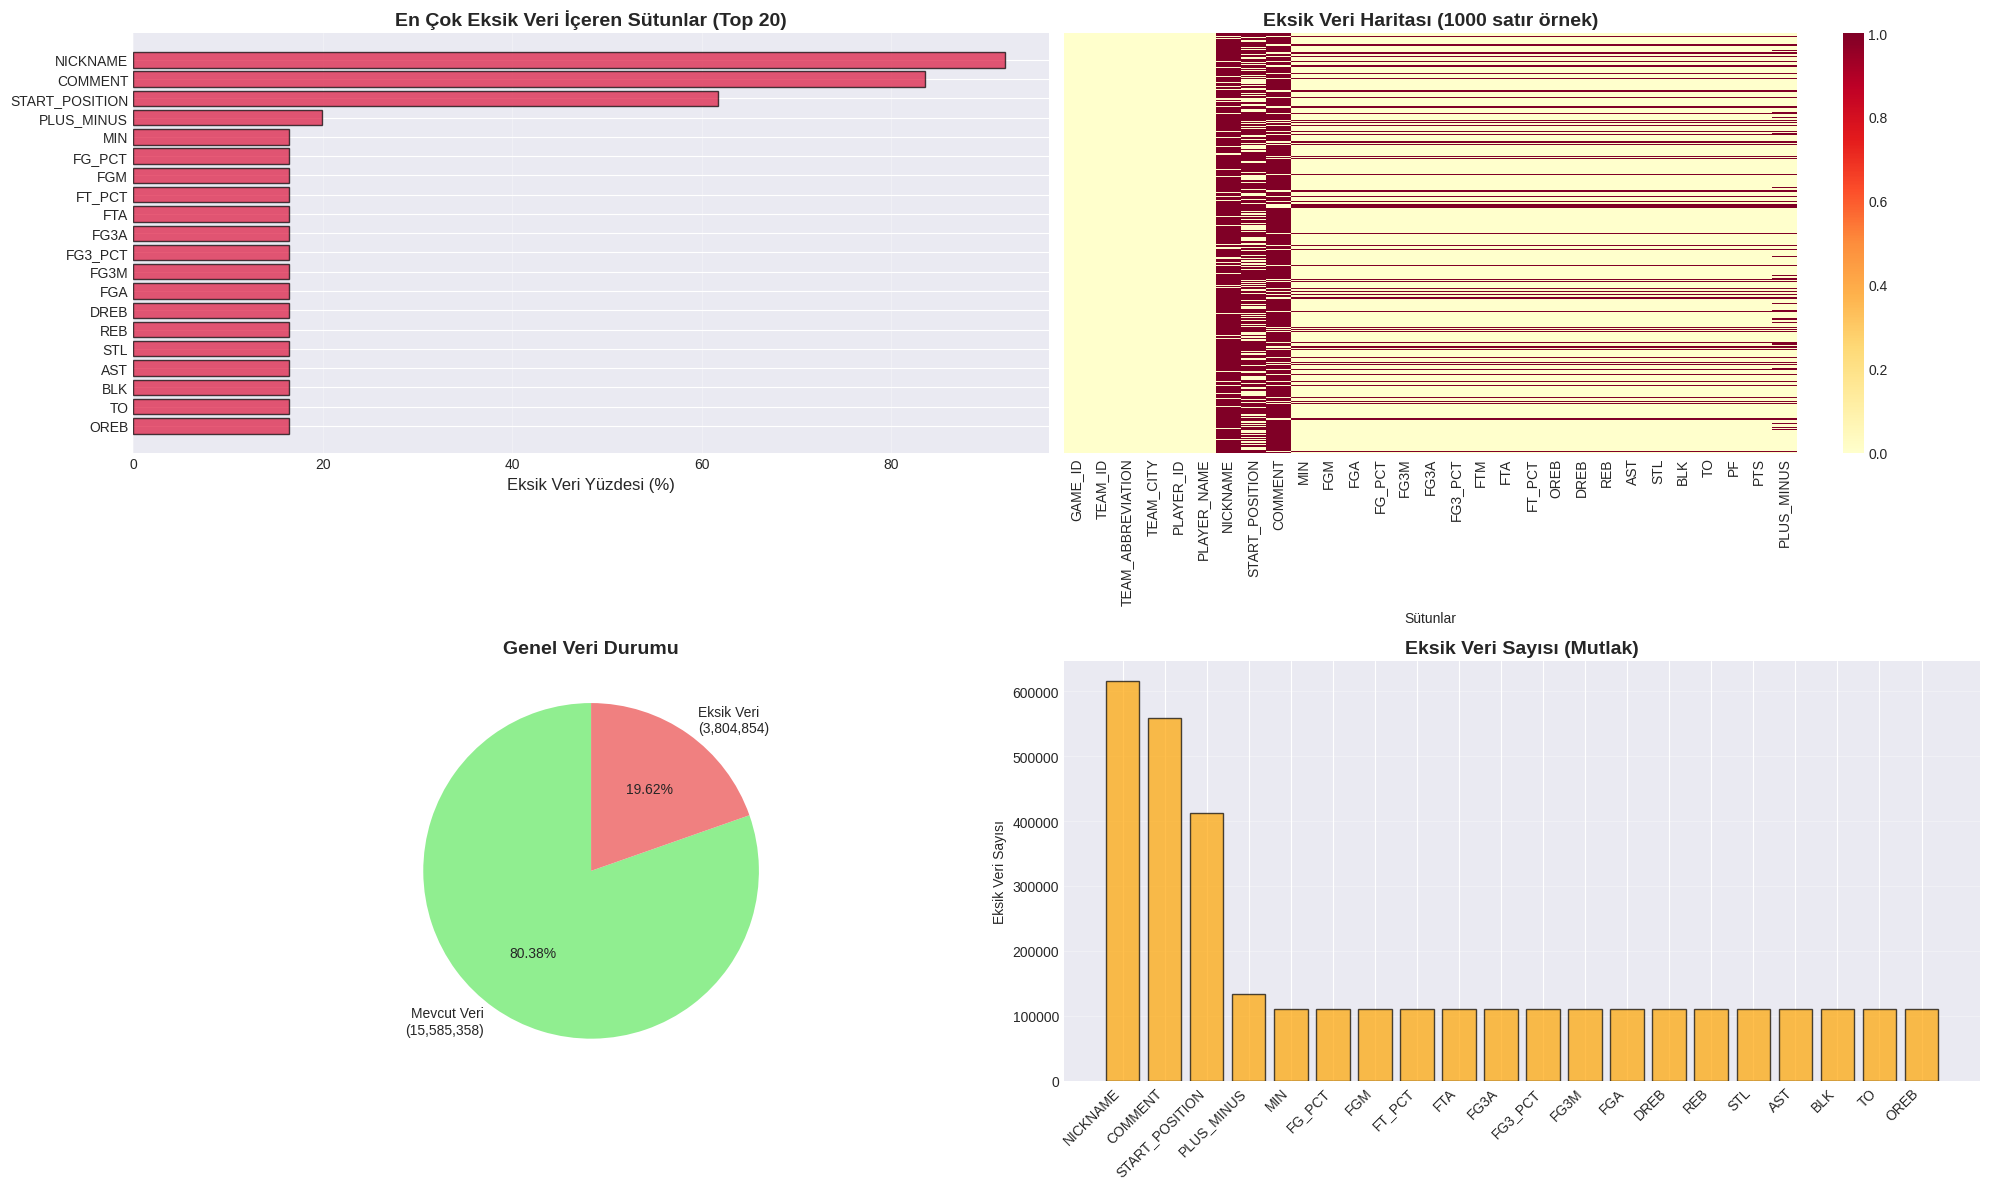

In [14]:
# Eksik veri görselleştirmesi - Detaylı
if len(missing_cols) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    # 1. Bar plot - tüm eksik sütunlar
    top_missing = missing_cols.head(20)
    axes[0, 0].barh(range(len(top_missing)), top_missing['Eksik_Yüzde'],
                   color='crimson', edgecolor='black', alpha=0.7)
    axes[0, 0].set_yticks(range(len(top_missing)))
    axes[0, 0].set_yticklabels(top_missing['Sütun'])
    axes[0, 0].set_xlabel('Eksik Veri Yüzdesi (%)', fontsize=12)
    axes[0, 0].set_title('En Çok Eksik Veri İçeren Sütunlar (Top 20)',
                        fontsize=14, fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
    axes[0, 0].invert_yaxis()

    # 2. Heatmap - rastgele 1000 satır
    sample_size = min(1000, len(df))
    sample_df = df.sample(sample_size, random_state=42)
    sns.heatmap(sample_df.isnull(), cbar=True, yticklabels=False,
               cmap='YlOrRd', ax=axes[0, 1])
    axes[0, 1].set_title(f'Eksik Veri Haritası ({sample_size} satır örnek)',
                        fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Sütunlar')

    # 3. Pie chart - Eksik vs Mevcut
    total_cells = len(df) * len(df.columns)
    missing_cells = missing_cols['Eksik_Sayı'].sum()
    present_cells = total_cells - missing_cells

    axes[1, 0].pie([present_cells, missing_cells],
                  labels=[f'Mevcut Veri\n({present_cells:,})',
                         f'Eksik Veri\n({missing_cells:,})'],
                  autopct='%1.2f%%', startangle=90,
                  colors=['lightgreen', 'lightcoral'])
    axes[1, 0].set_title('Genel Veri Durumu', fontsize=14, fontweight='bold')

    # 4. Sütun bazında eksiklik sayısı
    axes[1, 1].bar(range(len(top_missing)), top_missing['Eksik_Sayı'],
                  color='orange', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xticks(range(len(top_missing)))
    axes[1, 1].set_xticklabels(top_missing['Sütun'], rotation=45, ha='right')
    axes[1, 1].set_ylabel('Eksik Veri Sayısı')
    axes[1, 1].set_title('Eksik Veri Sayısı (Mutlak)', fontsize=14, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("✅ Eksik veri olmadığı için görselleştirme yapılmadı.")

## ⛹️ Oyuncu Performans İstatistikleri - Detaylı Analiz

In [17]:
# Temel performans metrikleri
performance_cols = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TO', 'PF', 'MIN']
available_perf_cols = [col for col in performance_cols if col in df.columns]

if available_perf_cols:
    print("="*70)
    print("⛹️ OYUNCU PERFORMANS İSTATİSTİKLERİ - DETAYLI")
    print("="*70)

    for col in available_perf_cols:
        # 'MIN' sütunu string olduğundan, sayısal işlemlere geçmeden önce dönüştürün.
        if col == 'MIN' and df[col].dtype == 'object':
            # 'MM:SS' formatını ondalık dakikaya çevir
            # NaN değerler otomatik olarak dönüştürme sonrası da NaN kalacaktır.
            # Use pd.to_numeric with errors='coerce' for robust conversion
            df['MIN_numeric_converted'] = pd.to_numeric(df[col].str.replace(':', '.', regex=False), errors='coerce')
            data = df['MIN_numeric_converted'].dropna()
        else:
            data = df[col].dropna()

        # Sadece sayısal veriler için istatistikleri göster
        if pd.api.types.is_numeric_dtype(data):
            print(f"\n📊 {col}:")
            print(f"  Ortalama: {data.mean():.3f}")
            print(f"  Medyan: {data.median():.3f}")
            print(f"  Mod: {data.mode().values[0] if len(data.mode()) > 0 else 'N/A'}")
            print(f"  Std Sapma: {data.std():.3f}")
            print(f"  Varyans: {data.var():.3f}")
            print(f"  Min: {data.min():.1f}")
            print(f"  Q1 (25%): {data.quantile(0.25):.1f}")
            print(f"  Q2 (50%): {data.quantile(0.50):.1f}")
            print(f"  Q3 (75%): {data.quantile(0.75):.1f}")
            print(f"  90th Percentile: {data.quantile(0.90):.1f}")
            print(f"  95th Percentile: {data.quantile(0.95):.1f}")
            print(f"  99th Percentile: {data.quantile(0.99):.1f}")
            print(f"  Max: {data.max():.1f}")
            print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.1f}")
            print(f"  Çarpıklık (Skewness): {data.skew():.3f}")
            print(f"  Basıklık (Kurtosis): {data.kurtosis():.3f}")
            print(f"  Toplam: {data.sum():,.0f}")
            print(f"  Sıfır Değer: {(data == 0).sum():,} ({(data == 0).sum()/len(data)*100:.2f}%)")
        else:
            print(f"\n📊 {col}: Sayısal bir sütun değil veya dönüştürülemedi. İstatistikler gösterilemedi.")




⛹️ OYUNCU PERFORMANS İSTATİSTİKLERİ - DETAYLI

📊 PTS:
  Ortalama: 9.688
  Medyan: 8.000
  Mod: 0.0
  Std Sapma: 8.082
  Varyans: 65.321
  Min: 0.0
  Q1 (25%): 3.0
  Q2 (50%): 8.0
  Q3 (75%): 14.0
  90th Percentile: 21.0
  95th Percentile: 25.0
  99th Percentile: 34.0
  Max: 81.0
  IQR: 11.0
  Çarpıklık (Skewness): 1.050
  Basıklık (Kurtosis): 1.145
  Toplam: 5,415,113
  Sıfır Değer: 66,121 (11.83%)

📊 REB:
  Ortalama: 4.058
  Medyan: 3.000
  Mod: 2.0
  Std Sapma: 3.483
  Varyans: 12.128
  Min: 0.0
  Q1 (25%): 1.0
  Q2 (50%): 3.0
  Q3 (75%): 6.0
  90th Percentile: 9.0
  95th Percentile: 11.0
  99th Percentile: 15.0
  Max: 31.0
  IQR: 5.0
  Çarpıklık (Skewness): 1.306
  Basıklık (Kurtosis): 2.169
  Toplam: 2,268,176
  Sıfır Değer: 65,319 (11.69%)

📊 AST:
  Ortalama: 2.104
  Medyan: 1.000
  Mod: 0.0
  Std Sapma: 2.475
  Varyans: 6.128
  Min: 0.0
  Q1 (25%): 0.0
  Q2 (50%): 1.0
  Q3 (75%): 3.0
  90th Percentile: 5.0
  95th Percentile: 7.0
  99th Percentile: 11.0
  Max: 25.0
  IQR: 3.0
  Ça

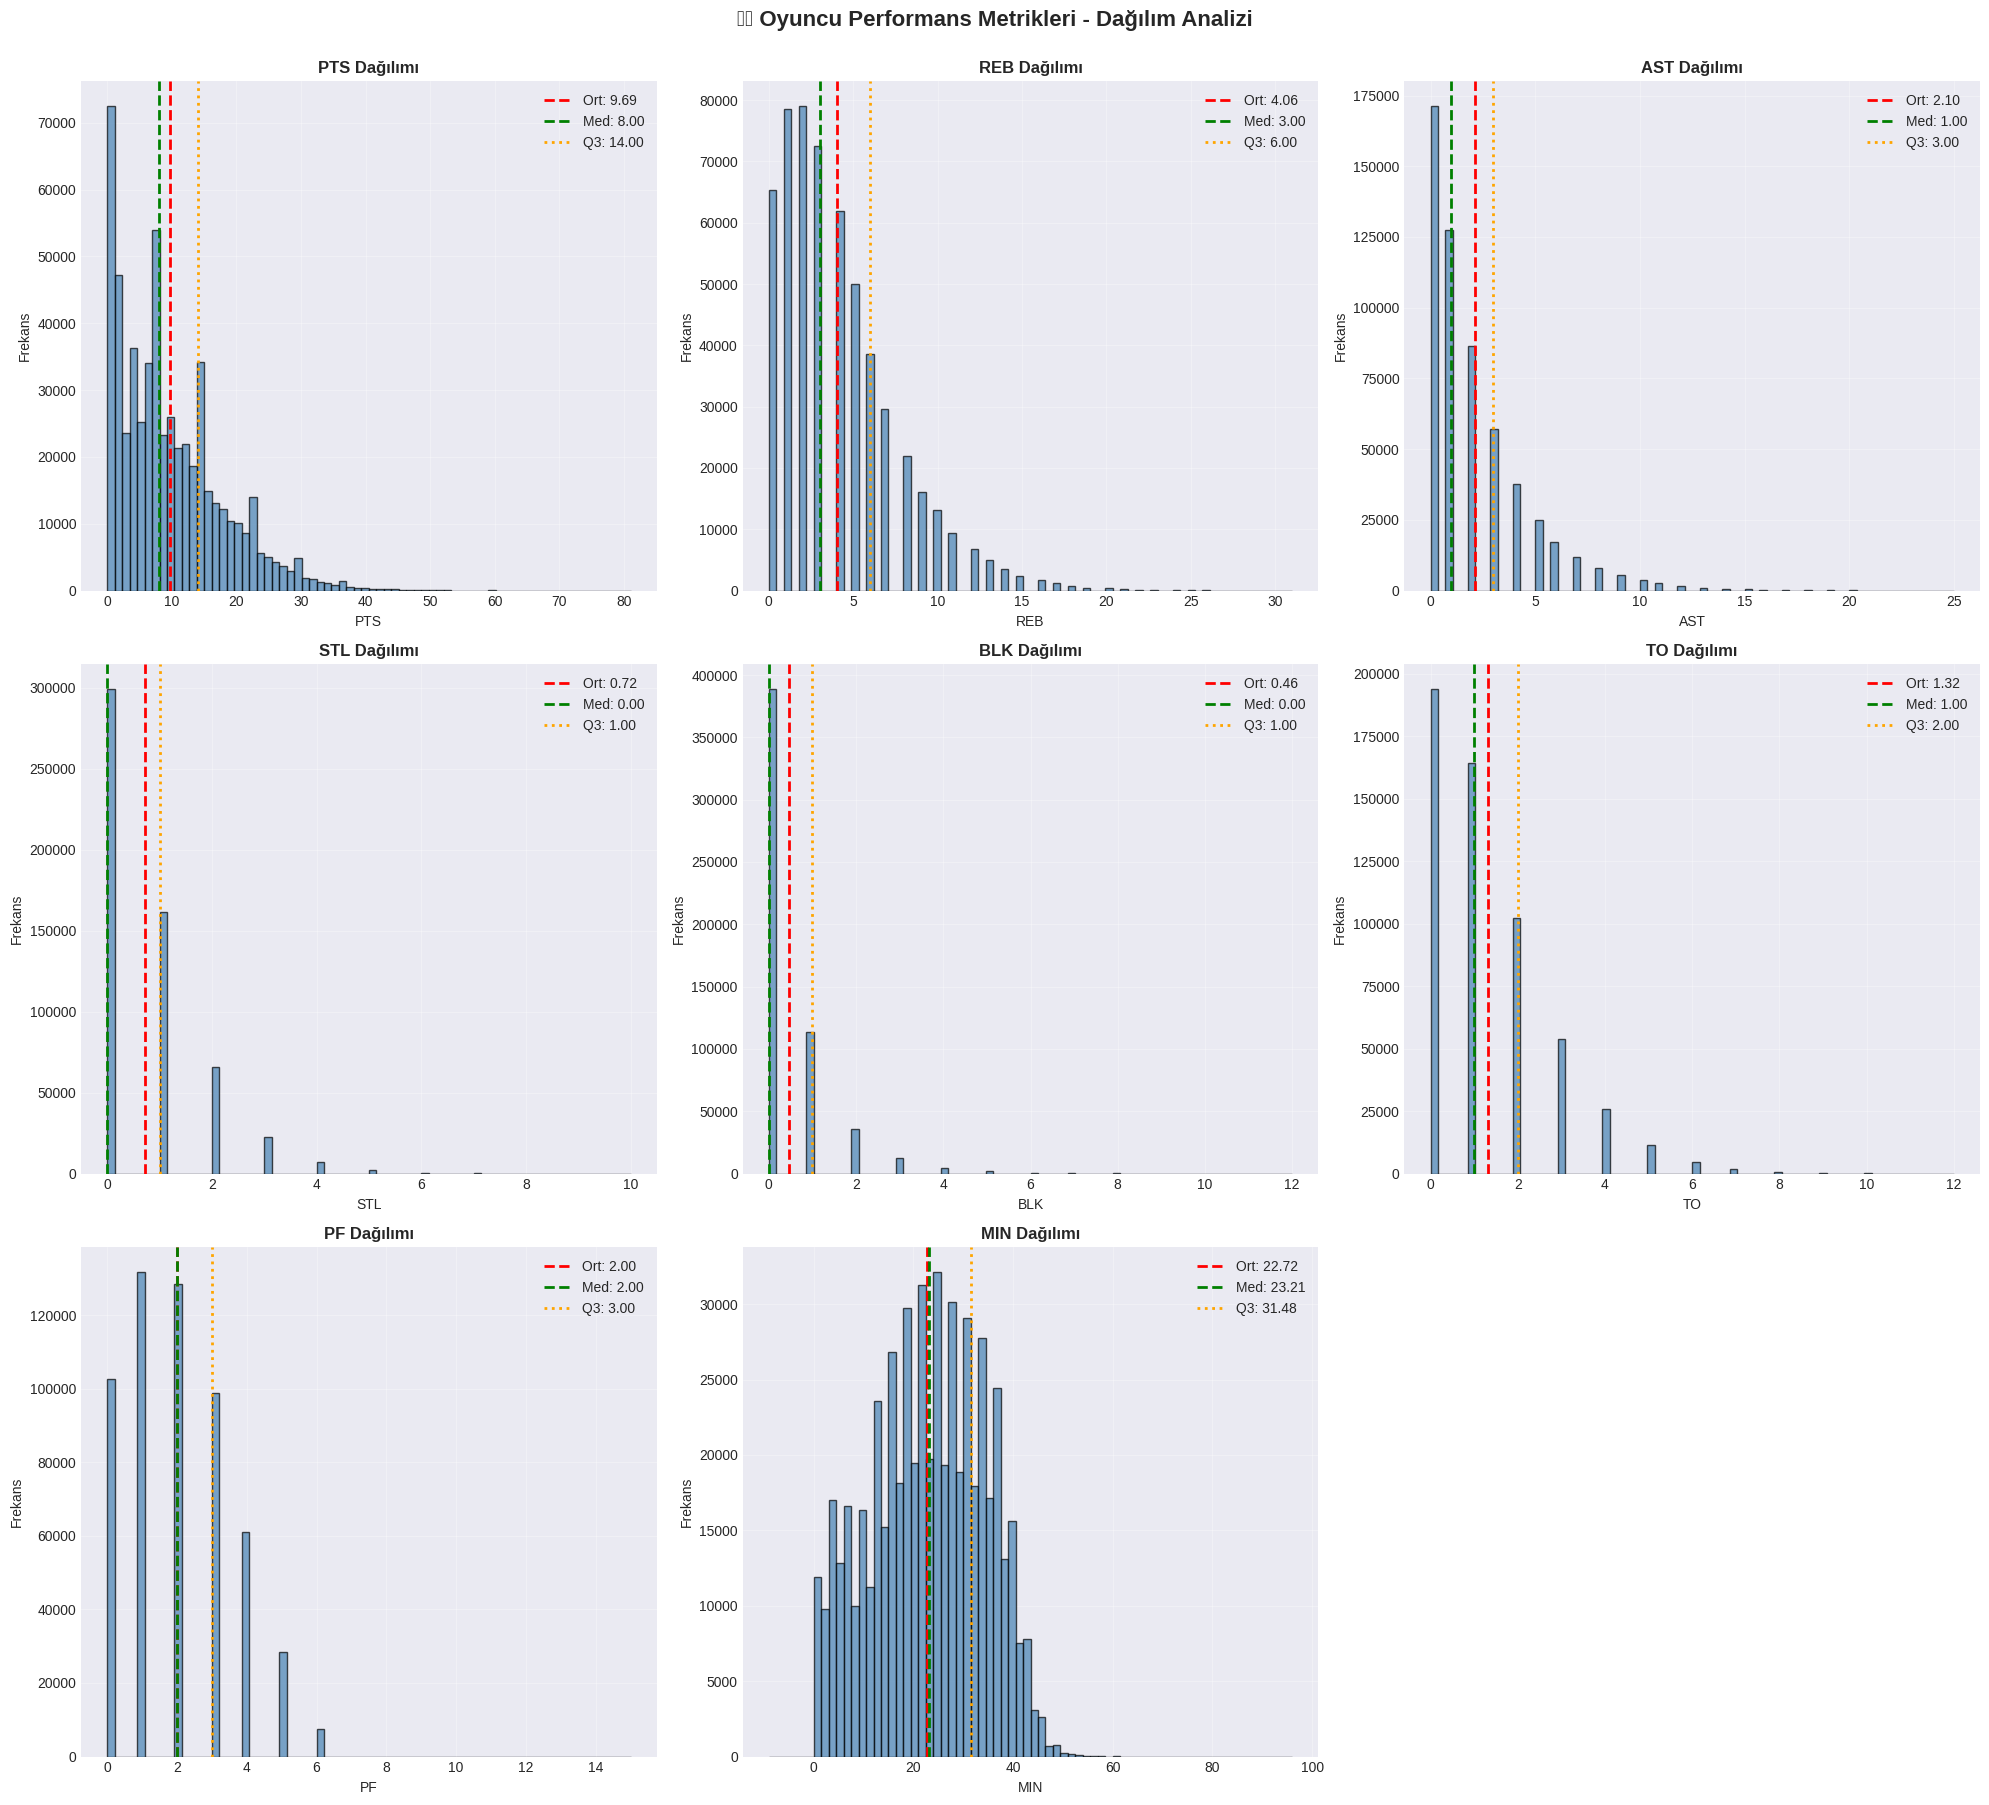

In [19]:
# Performans metrikleri dağılımları - Kapsamlı
if available_perf_cols:
    n_metrics = len(available_perf_cols)
    n_rows = (n_metrics + 2) // 3

    fig, axes = plt.subplots(n_rows, 3, figsize=(20, 6*n_rows))
    fig.suptitle('⛹️ Oyuncu Performans Metrikleri - Dağılım Analizi',
                fontsize=16, fontweight='bold', y=1.00)
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

    for idx, col in enumerate(available_perf_cols):
        # Use the numeric 'MIN' column if it exists
        if col == 'MIN' and 'MIN_numeric_converted' in df.columns:
            data = df['MIN_numeric_converted'].dropna()
        else:
            data = df[col].dropna()

        # Histogram
        axes[idx].hist(data, bins=70, color='steelblue',
                      edgecolor='black', alpha=0.7)
        axes[idx].axvline(data.mean(), color='red', linestyle='--',
                         linewidth=2, label=f"Ort: {data.mean():.2f}")
        axes[idx].axvline(data.median(), color='green', linestyle='--',
                         linewidth=2, label=f"Med: {data.median():.2f}")
        axes[idx].axvline(data.quantile(0.75), color='orange', linestyle=':',
                         linewidth=2, label=f"Q3: {data.quantile(0.75):.2f}")
        axes[idx].set_title(f'{col} Dağılımı', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frekans')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

    # Boş grafikleri kaldır
    for idx in range(len(available_perf_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

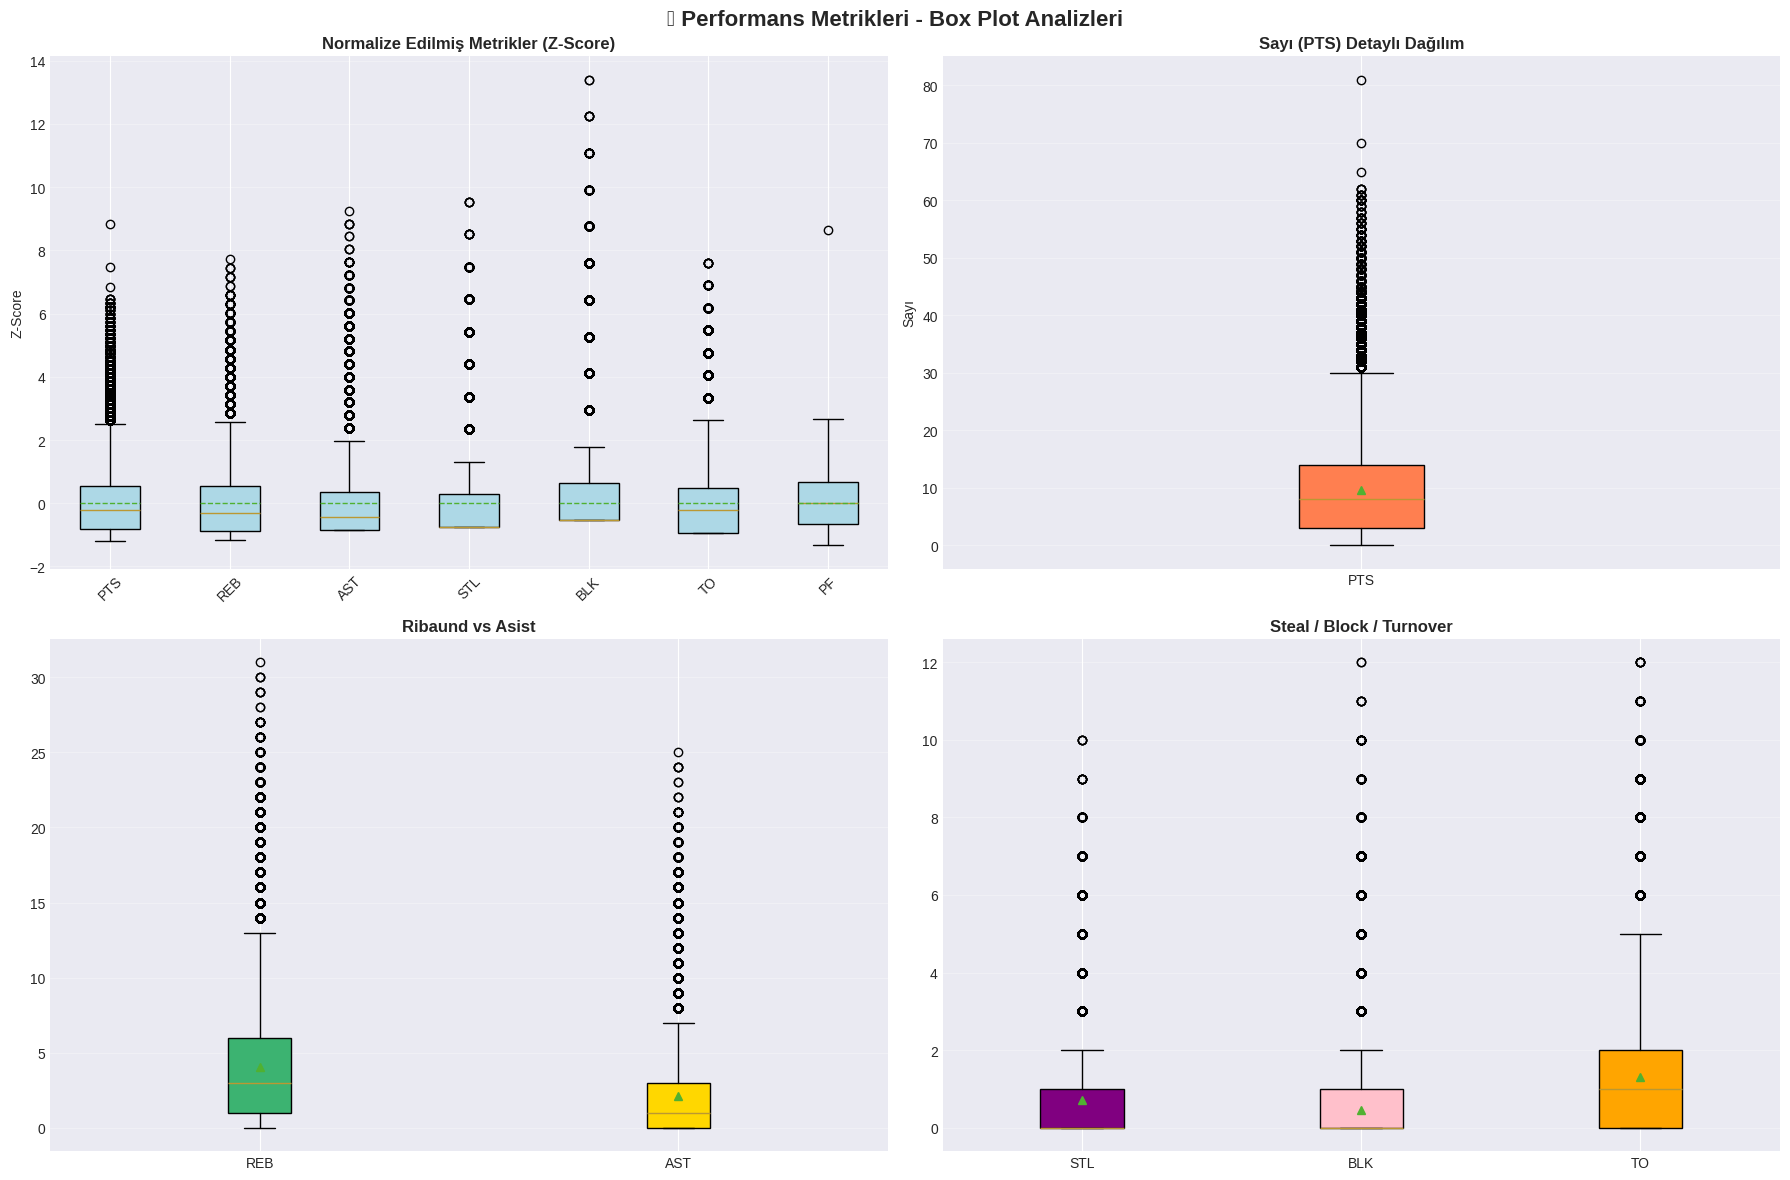

In [20]:
# Box plot karşılaştırmaları
if len(available_perf_cols) >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('📦 Performans Metrikleri - Box Plot Analizleri',
                fontsize=16, fontweight='bold')

    # Tüm metrikleri normalize et ve karşılaştır
    normalized_data = []
    labels = []

    for col in available_perf_cols[:7]:  # İlk 7 metrik
        data = df[col].dropna()
        normalized = (data - data.mean()) / data.std()
        normalized_data.append(normalized)
        labels.append(col)

    # 1. Normalize edilmiş karşılaştırma
    bp1 = axes[0, 0].boxplot(normalized_data, labels=labels, patch_artist=True,
                             showmeans=True, meanline=True)
    for patch in bp1['boxes']:
        patch.set_facecolor('lightblue')
    axes[0, 0].set_title('Normalize Edilmiş Metrikler (Z-Score)', fontweight='bold')
    axes[0, 0].set_ylabel('Z-Score')
    axes[0, 0].grid(axis='y', alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2-4. Bireysel detaylı box plotlar
    if 'PTS' in df.columns:
        bp2 = axes[0, 1].boxplot([df['PTS'].dropna()], labels=['PTS'],
                                 patch_artist=True, showmeans=True)
        bp2['boxes'][0].set_facecolor('coral')
        axes[0, 1].set_title('Sayı (PTS) Detaylı Dağılım', fontweight='bold')
        axes[0, 1].set_ylabel('Sayı')
        axes[0, 1].grid(axis='y', alpha=0.3)

    if 'REB' in df.columns and 'AST' in df.columns:
        bp3 = axes[1, 0].boxplot([df['REB'].dropna(), df['AST'].dropna()],
                                 labels=['REB', 'AST'], patch_artist=True,
                                 showmeans=True)
        bp3['boxes'][0].set_facecolor('mediumseagreen')
        bp3['boxes'][1].set_facecolor('gold')
        axes[1, 0].set_title('Ribaund vs Asist', fontweight='bold')
        axes[1, 0].grid(axis='y', alpha=0.3)

    if 'STL' in df.columns and 'BLK' in df.columns and 'TO' in df.columns:
        bp4 = axes[1, 1].boxplot([df['STL'].dropna(), df['BLK'].dropna(), df['TO'].dropna()],
                                 labels=['STL', 'BLK', 'TO'], patch_artist=True,
                                 showmeans=True)
        bp4['boxes'][0].set_facecolor('purple')
        bp4['boxes'][1].set_facecolor('pink')
        bp4['boxes'][2].set_facecolor('orange')
        axes[1, 1].set_title('Steal / Block / Turnover', fontweight='bold')
        axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 🏆 Top Oyuncular - Çoklu Kategori Analizi

In [21]:
# Tek maçta en yüksek sayı atan oyuncular
if 'PTS' in df.columns and 'PLAYER_NAME' in df.columns:
    print("="*70)
    print("🏆 TEK MAÇTA EN YÜKSEK SAYI ATAN OYUNCULAR (Top 30)")
    print("="*70)

    cols_to_show = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'PTS']
    if 'FGM' in df.columns:
        cols_to_show.extend(['FGM', 'FGA'])
    if 'FG3M' in df.columns:
        cols_to_show.extend(['FG3M'])
    if 'FTM' in df.columns:
        cols_to_show.extend(['FTM'])
    if 'MIN' in df.columns:
        cols_to_show.append('MIN')

    top_scorers = df.nlargest(30, 'PTS')[cols_to_show]
    print(top_scorers.to_string(index=False))

🏆 TEK MAÇTA EN YÜKSEK SAYI ATAN OYUNCULAR (Top 30)
       PLAYER_NAME TEAM_ABBREVIATION    PTS    FGM    FGA   FG3M    FTM   MIN
       Kobe Bryant               LAL 81.000 28.000 46.000  7.000 18.000 41:56
      Devin Booker               PHX 70.000 21.000 40.000  4.000 24.000 44:58
       Kobe Bryant               LAL 65.000 23.000 39.000  8.000 11.000 49:58
     Stephen Curry               GSW 62.000 18.000 31.000  8.000 18.000 36:26
       Kobe Bryant               LAL 62.000 18.000 31.000  4.000 22.000 32:53
     Tracy McGrady               ORL 62.000 20.000 37.000  5.000 17.000 45:50
   Carmelo Anthony               NYK 62.000 23.000 35.000  6.000 10.000 38:39
    Damian Lillard               POR 61.000 17.000 32.000  9.000 18.000 41:05
    Damian Lillard               POR 61.000 17.000 37.000 11.000 16.000 45:08
       Kobe Bryant               LAL 61.000 19.000 31.000  3.000 20.000 36:48
      James Harden               HOU 61.000 19.000 34.000  9.000 14.000 36:40
      James H

In [22]:
# Tek maçta en çok ribaund alan oyuncular
if 'REB' in df.columns and 'PLAYER_NAME' in df.columns:
    print("\n" + "="*70)
    print("🏀 TEK MAÇTA EN ÇOK RİBAUND ALAN OYUNCULAR (Top 30)")
    print("="*70)

    cols_reb = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'REB']
    if 'OREB' in df.columns:
        cols_reb.append('OREB')
    if 'DREB' in df.columns:
        cols_reb.append('DREB')
    if 'PTS' in df.columns:
        cols_reb.append('PTS')
    if 'MIN' in df.columns:
        cols_reb.append('MIN')

    top_rebounders = df.nlargest(30, 'REB')[[c for c in cols_reb if c in df.columns]]
    print(top_rebounders.to_string(index=False))


🏀 TEK MAÇTA EN ÇOK RİBAUND ALAN OYUNCULAR (Top 30)
       PLAYER_NAME TEAM_ABBREVIATION    REB   OREB   DREB    PTS   MIN
        Kevin Love               MIN 31.000 12.000 19.000 31.000 40:39
       Enes Kanter               POR 30.000 12.000 18.000 24.000 37:03
      Andrew Bynum               LAL 30.000  8.000 22.000 16.000 36:41
     Dwight Howard               CHA 30.000 11.000 19.000 32.000 34:02
       Ivica Zubac               LAC 29.000 12.000 17.000 31.000 35:40
    Andre Drummond               DET 29.000 11.000 18.000 25.000 43:13
    Timofey Mozgov               DEN 29.000  9.000 20.000 23.000 42:45
    Nikola Vucevic               ORL 29.000 11.000 18.000 20.000 46:34
       Rudy Gobert               UTA 28.000  8.000 20.000 24.000 32:28
    Tyson Chandler               NYK 28.000 10.000 18.000 16.000 42:15
      Nikola Jokic               DEN 27.000  7.000 20.000 40.000 39:41
      Marcus Camby               LAC 27.000 10.000 17.000 19.000 41:42
       Ben Wallace       

In [23]:
# Tek maçta en çok asist yapan oyuncular
if 'AST' in df.columns and 'PLAYER_NAME' in df.columns:
    print("\n" + "="*70)
    print("🤝 TEK MAÇTA EN ÇOK ASİST YAPAN OYUNCULAR (Top 30)")
    print("="*70)

    cols_ast = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AST', 'PTS']
    if 'TO' in df.columns:
        cols_ast.append('TO')
    if 'MIN' in df.columns:
        cols_ast.append('MIN')

    top_assists = df.nlargest(30, 'AST')[[c for c in cols_ast if c in df.columns]]
    print(top_assists.to_string(index=False))


🤝 TEK MAÇTA EN ÇOK ASİST YAPAN OYUNCULAR (Top 30)
      PLAYER_NAME TEAM_ABBREVIATION    AST    PTS    TO   MIN
      Rajon Rondo               NOP 25.000  2.000 3.000 30:18
Russell Westbrook               WAS 24.000 14.000 6.000 38:38
   Ramon Sessions               MIL 24.000 20.000 2.000 44:27
      Rajon Rondo               BOS 24.000 10.000 7.000 45:20
Russell Westbrook               OKC 24.000 24.000 3.000 49:35
       Steve Nash               PHX 23.000 17.000 3.000 39:05
      Rajon Rondo               BOS 23.000 12.000 5.000 43:30
      Chris Duhon               NYK 22.000 12.000 3.000 45:15
       Steve Nash               PHX 22.000 28.000 4.000 55:28
Russell Westbrook               OKC 22.000 26.000 5.000 34:01
Russell Westbrook               WAS 21.000 28.000 3.000 40:08
Russell Westbrook               WAS 21.000 35.000 4.000 39:18
       Steve Nash               PHX 21.000 15.000 2.000 33:56
       Chris Paul               NOH 21.000 19.000 2.000 35:06
   Deron Williams  

In [24]:
# Daha fazla kategori - Steal, Block
if 'STL' in df.columns and 'PLAYER_NAME' in df.columns:
    print("\n" + "="*70)
    print("🛡️ TEK MAÇTA EN ÇOK TOP ÇALAN OYUNCULAR (Top 20)")
    print("="*70)

    cols_stl = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'STL', 'PTS', 'MIN']
    top_steals = df.nlargest(20, 'STL')[[c for c in cols_stl if c in df.columns]]
    print(top_steals.to_string(index=False))

if 'BLK' in df.columns and 'PLAYER_NAME' in df.columns:
    print("\n" + "="*70)
    print("🚫 TEK MAÇTA EN ÇOK BLOK YAPAN OYUNCULAR (Top 20)")
    print("="*70)

    cols_blk = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'BLK', 'REB', 'MIN']
    top_blocks = df.nlargest(20, 'BLK')[[c for c in cols_blk if c in df.columns]]
    print(top_blocks.to_string(index=False))


🛡️ TEK MAÇTA EN ÇOK TOP ÇALAN OYUNCULAR (Top 20)
            PLAYER_NAME TEAM_ABBREVIATION    STL    PTS   MIN
         T.J. McConnell               IND 10.000 16.000 36:27
            Brandon Roy               POR 10.000 22.000 39:04
           Lou Williams               LAC 10.000 31.000 40:01
         Draymond Green               GSW 10.000  4.000 37:44
         Mario Chalmers               MIA  9.000  6.000 30:32
             Chris Paul               NOH  9.000 31.000 40:38
           Rafer Alston               HOU  9.000 14.000 41:13
          Dirk Nowitzki               DAL  9.000 18.000 44:24
              John Wall               WAS  9.000 29.000 44:48
Michael Carter-Williams               PHI  9.000 22.000 36:10
           Eric Bledsoe               LAC  9.000 22.000    44
            Paul George               LAC  8.000 14.000 26:35
        Dejounte Murray               SAS  8.000 27.000 36:09
           Delonte West               CLE  8.000 13.000 32:46
             Chris P

In [25]:
# En çok turnover yapan oyuncular
if 'TO' in df.columns and 'PLAYER_NAME' in df.columns:
    print("\n" + "="*70)
    print("❌ TEK MAÇTA EN ÇOK TOP KAYBI YAPAN OYUNCULAR (Top 20)")
    print("="*70)

    cols_to = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'TO', 'AST', 'PTS', 'MIN']
    top_turnovers = df.nlargest(20, 'TO')[[c for c in cols_to if c in df.columns]]
    print(top_turnovers.to_string(index=False))


❌ TEK MAÇTA EN ÇOK TOP KAYBI YAPAN OYUNCULAR (Top 20)
         PLAYER_NAME TEAM_ABBREVIATION     TO    AST    PTS   MIN
         Dwyane Wade               MIA 12.000  5.000 41.000 42:25
         Paul Pierce               BOS 12.000  6.000 35.000 44:46
       Allen Iverson               PHI 12.000  5.000 33.000 44:35
      Gilbert Arenas               WAS 12.000  8.000 21.000 42:09
        James Harden               HOU 12.000 15.000 29.000 40:32
        James Harden               HOU 12.000  5.000 14.000 43:15
Duane Washington Jr.               PHX 11.000  4.000 31.000 38:47
         Luka Doncic               DAL 11.000  9.000 42.000 38:21
        James Harden               HOU 11.000  8.000 32.000 27:42
         Kobe Bryant               LAL 11.000  5.000 39.000 47:15
       Dwight Howard               ORL 11.000  1.000 21.000 37:44
          Mike Bibby               SAC 11.000  9.000 23.000 45:06
       Allen Iverson               PHI 11.000  7.000 31.000 41:40
   Richard Jefferson 

## 🎯 Şut Verimliliği - Deep Dive Analizi

In [26]:
# Şut yüzdelerini hesapla
print("="*70)
print("🎯 ŞUT VERİMLİLİĞİ - DETAYLI ANALİZ")
print("="*70)

# Field Goal Percentage
if 'FGM' in df.columns and 'FGA' in df.columns:
    df['FG_PCT_calc'] = df.apply(
        lambda row: row['FGM'] / row['FGA'] if row['FGA'] > 0 else np.nan, axis=1
    )

    fg_data = df['FG_PCT_calc'].dropna()
    print("\n📊 FIELD GOAL PERCENTAGE (FG%):")
    print(f"  Ortalama: {fg_data.mean():.4f} ({fg_data.mean()*100:.2f}%)")
    print(f"  Medyan: {fg_data.median():.4f} ({fg_data.median()*100:.2f}%)")
    print(f"  Std Sapma: {fg_data.std():.4f}")
    print(f"  Min: {fg_data.min():.4f} ({fg_data.min()*100:.2f}%)")
    print(f"  Max: {fg_data.max():.4f} ({fg_data.max()*100:.2f}%)")
    print(f"  Q1: {fg_data.quantile(0.25):.4f}")
    print(f"  Q3: {fg_data.quantile(0.75):.4f}")
    print(f"  IQR: {fg_data.quantile(0.75) - fg_data.quantile(0.25):.4f}")
    print(f"  Toplam Şut Denemesi: {df['FGA'].sum():,.0f}")
    print(f"  Toplam Şut İsabet: {df['FGM'].sum():,.0f}")
    print(f"  Genel FG%: {df['FGM'].sum() / df['FGA'].sum():.4f}")

# 3-Point Percentage
if 'FG3M' in df.columns and 'FG3A' in df.columns:
    df['FG3_PCT_calc'] = df.apply(
        lambda row: row['FG3M'] / row['FG3A'] if row['FG3A'] > 0 else np.nan, axis=1
    )

    fg3_data = df['FG3_PCT_calc'].dropna()
    print("\n🏹 3-POINT PERCENTAGE (3P%):")
    print(f"  Ortalama: {fg3_data.mean():.4f} ({fg3_data.mean()*100:.2f}%)")
    print(f"  Medyan: {fg3_data.median():.4f} ({fg3_data.median()*100:.2f}%)")
    print(f"  Std Sapma: {fg3_data.std():.4f}")
    print(f"  Min: {fg3_data.min():.4f} ({fg3_data.min()*100:.2f}%)")
    print(f"  Max: {fg3_data.max():.4f} ({fg3_data.max()*100:.2f}%)")
    print(f"  Q1: {fg3_data.quantile(0.25):.4f}")
    print(f"  Q3: {fg3_data.quantile(0.75):.4f}")
    print(f"  Toplam 3P Denemesi: {df['FG3A'].sum():,.0f}")
    print(f"  Toplam 3P İsabet: {df['FG3M'].sum():,.0f}")
    print(f"  Genel 3P%: {df['FG3M'].sum() / df['FG3A'].sum():.4f}")

# Free Throw Percentage
if 'FTM' in df.columns and 'FTA' in df.columns:
    df['FT_PCT_calc'] = df.apply(
        lambda row: row['FTM'] / row['FTA'] if row['FTA'] > 0 else np.nan, axis=1
    )

    ft_data = df['FT_PCT_calc'].dropna()
    print("\n🎯 FREE THROW PERCENTAGE (FT%):")
    print(f"  Ortalama: {ft_data.mean():.4f} ({ft_data.mean()*100:.2f}%)")
    print(f"  Medyan: {ft_data.median():.4f} ({ft_data.median()*100:.2f}%)")
    print(f"  Std Sapma: {ft_data.std():.4f}")
    print(f"  Min: {ft_data.min():.4f} ({ft_data.min()*100:.2f}%)")
    print(f"  Max: {ft_data.max():.4f} ({ft_data.max()*100:.2f}%)")
    print(f"  Q1: {ft_data.quantile(0.25):.4f}")
    print(f"  Q3: {ft_data.quantile(0.75):.4f}")
    print(f"  Toplam FT Denemesi: {df['FTA'].sum():,.0f}")
    print(f"  Toplam FT İsabet: {df['FTM'].sum():,.0f}")
    print(f"  Genel FT%: {df['FTM'].sum() / df['FTA'].sum():.4f}")

🎯 ŞUT VERİMLİLİĞİ - DETAYLI ANALİZ

📊 FIELD GOAL PERCENTAGE (FG%):
  Ortalama: 0.4396 (43.96%)
  Medyan: 0.4444 (44.44%)
  Std Sapma: 0.2386
  Min: 0.0000 (0.00%)
  Max: 1.0000 (100.00%)
  Q1: 0.3077
  Q3: 0.5714
  IQR: 0.2637
  Toplam Şut Denemesi: 4,413,739
  Toplam Şut İsabet: 2,005,719
  Genel FG%: 0.4544

🏹 3-POINT PERCENTAGE (3P%):
  Ortalama: 0.3235 (32.35%)
  Medyan: 0.3333 (33.33%)
  Std Sapma: 0.3089
  Min: 0.0000 (0.00%)
  Max: 1.0000 (100.00%)
  Q1: 0.0000
  Q3: 0.5000
  Toplam 3P Denemesi: 1,221,849
  Toplam 3P İsabet: 434,919
  Genel 3P%: 0.3560

🎯 FREE THROW PERCENTAGE (FT%):
  Ortalama: 0.7465 (74.65%)
  Medyan: 0.8000 (80.00%)
  Std Sapma: 0.2865
  Min: 0.0000 (0.00%)
  Max: 1.0000 (100.00%)
  Q1: 0.5000
  Q3: 1.0000
  Toplam FT Denemesi: 1,276,733
  Toplam FT İsabet: 968,761
  Genel FT%: 0.7588


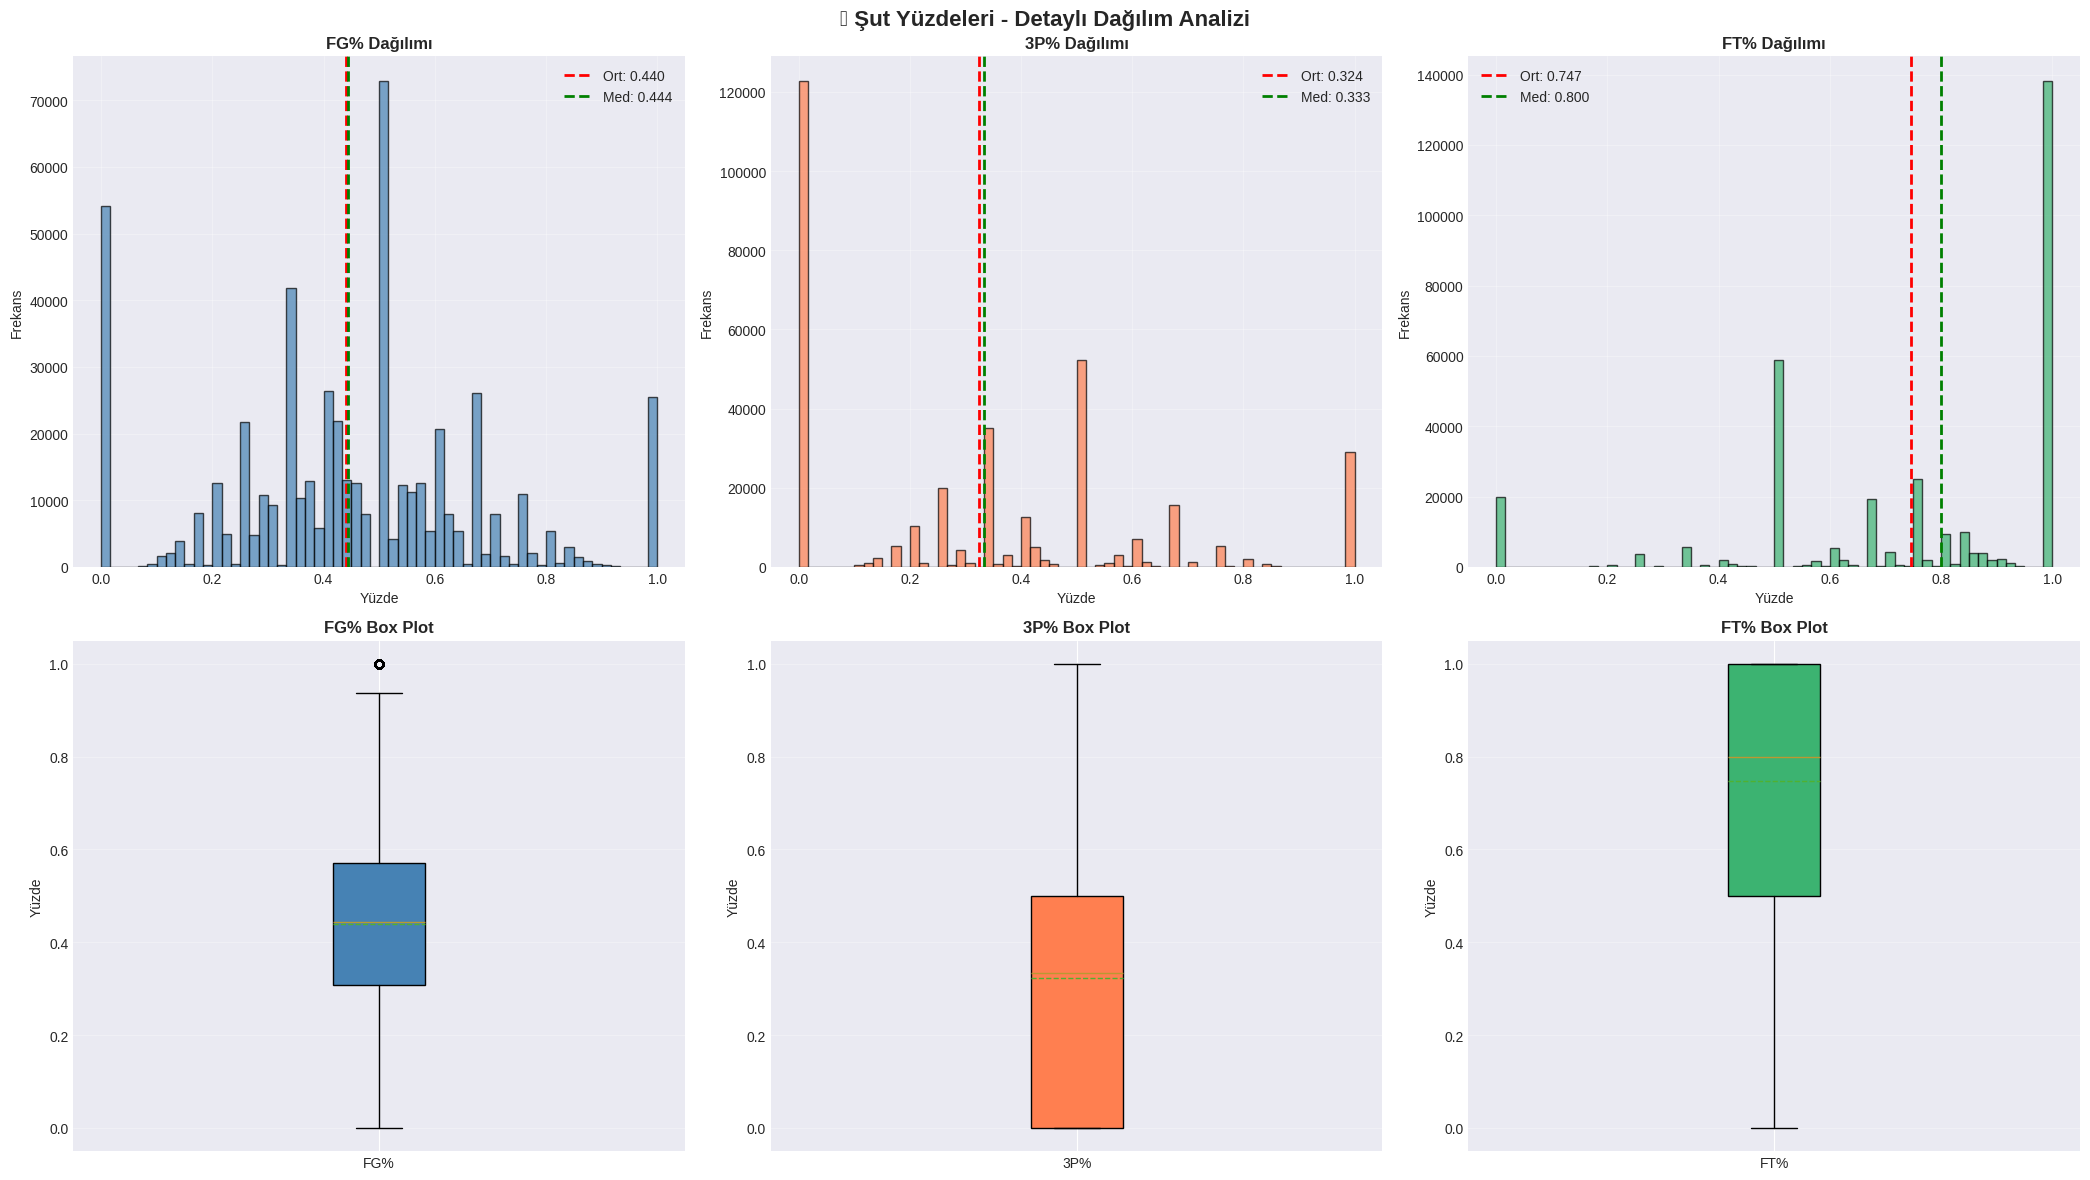

In [27]:
# Şut yüzdesi dağılımları - Kapsamlı görselleştirme
shooting_pcts = []
if 'FG_PCT_calc' in df.columns:
    shooting_pcts.append(('FG%', df['FG_PCT_calc'].dropna()))
if 'FG3_PCT_calc' in df.columns:
    shooting_pcts.append(('3P%', df['FG3_PCT_calc'].dropna()))
if 'FT_PCT_calc' in df.columns:
    shooting_pcts.append(('FT%', df['FT_PCT_calc'].dropna()))

if shooting_pcts:
    n_shooting = len(shooting_pcts)
    fig, axes = plt.subplots(2, n_shooting, figsize=(7*n_shooting, 12))
    fig.suptitle('🎯 Şut Yüzdeleri - Detaylı Dağılım Analizi',
                fontsize=16, fontweight='bold')

    if n_shooting == 1:
        axes = axes.reshape(-1, 1)

    colors = ['steelblue', 'coral', 'mediumseagreen']

    for idx, (name, data) in enumerate(shooting_pcts):
        # Veriyi 0-1 arasına sınırla
        data_clean = data[(data >= 0) & (data <= 1)]

        # 1. Histogram
        axes[0, idx].hist(data_clean, bins=60, color=colors[idx],
                         edgecolor='black', alpha=0.7)
        axes[0, idx].axvline(data_clean.mean(), color='red', linestyle='--',
                            linewidth=2, label=f"Ort: {data_clean.mean():.3f}")
        axes[0, idx].axvline(data_clean.median(), color='green', linestyle='--',
                            linewidth=2, label=f"Med: {data_clean.median():.3f}")
        axes[0, idx].set_title(f'{name} Dağılımı', fontsize=12, fontweight='bold')
        axes[0, idx].set_xlabel('Yüzde')
        axes[0, idx].set_ylabel('Frekans')
        axes[0, idx].legend()
        axes[0, idx].grid(alpha=0.3)

        # 2. Box plot
        bp = axes[1, idx].boxplot([data_clean], labels=[name],
                                  patch_artist=True, showmeans=True,
                                  meanline=True)
        bp['boxes'][0].set_facecolor(colors[idx])
        axes[1, idx].set_title(f'{name} Box Plot', fontsize=12, fontweight='bold')
        axes[1, idx].set_ylabel('Yüzde')
        axes[1, idx].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

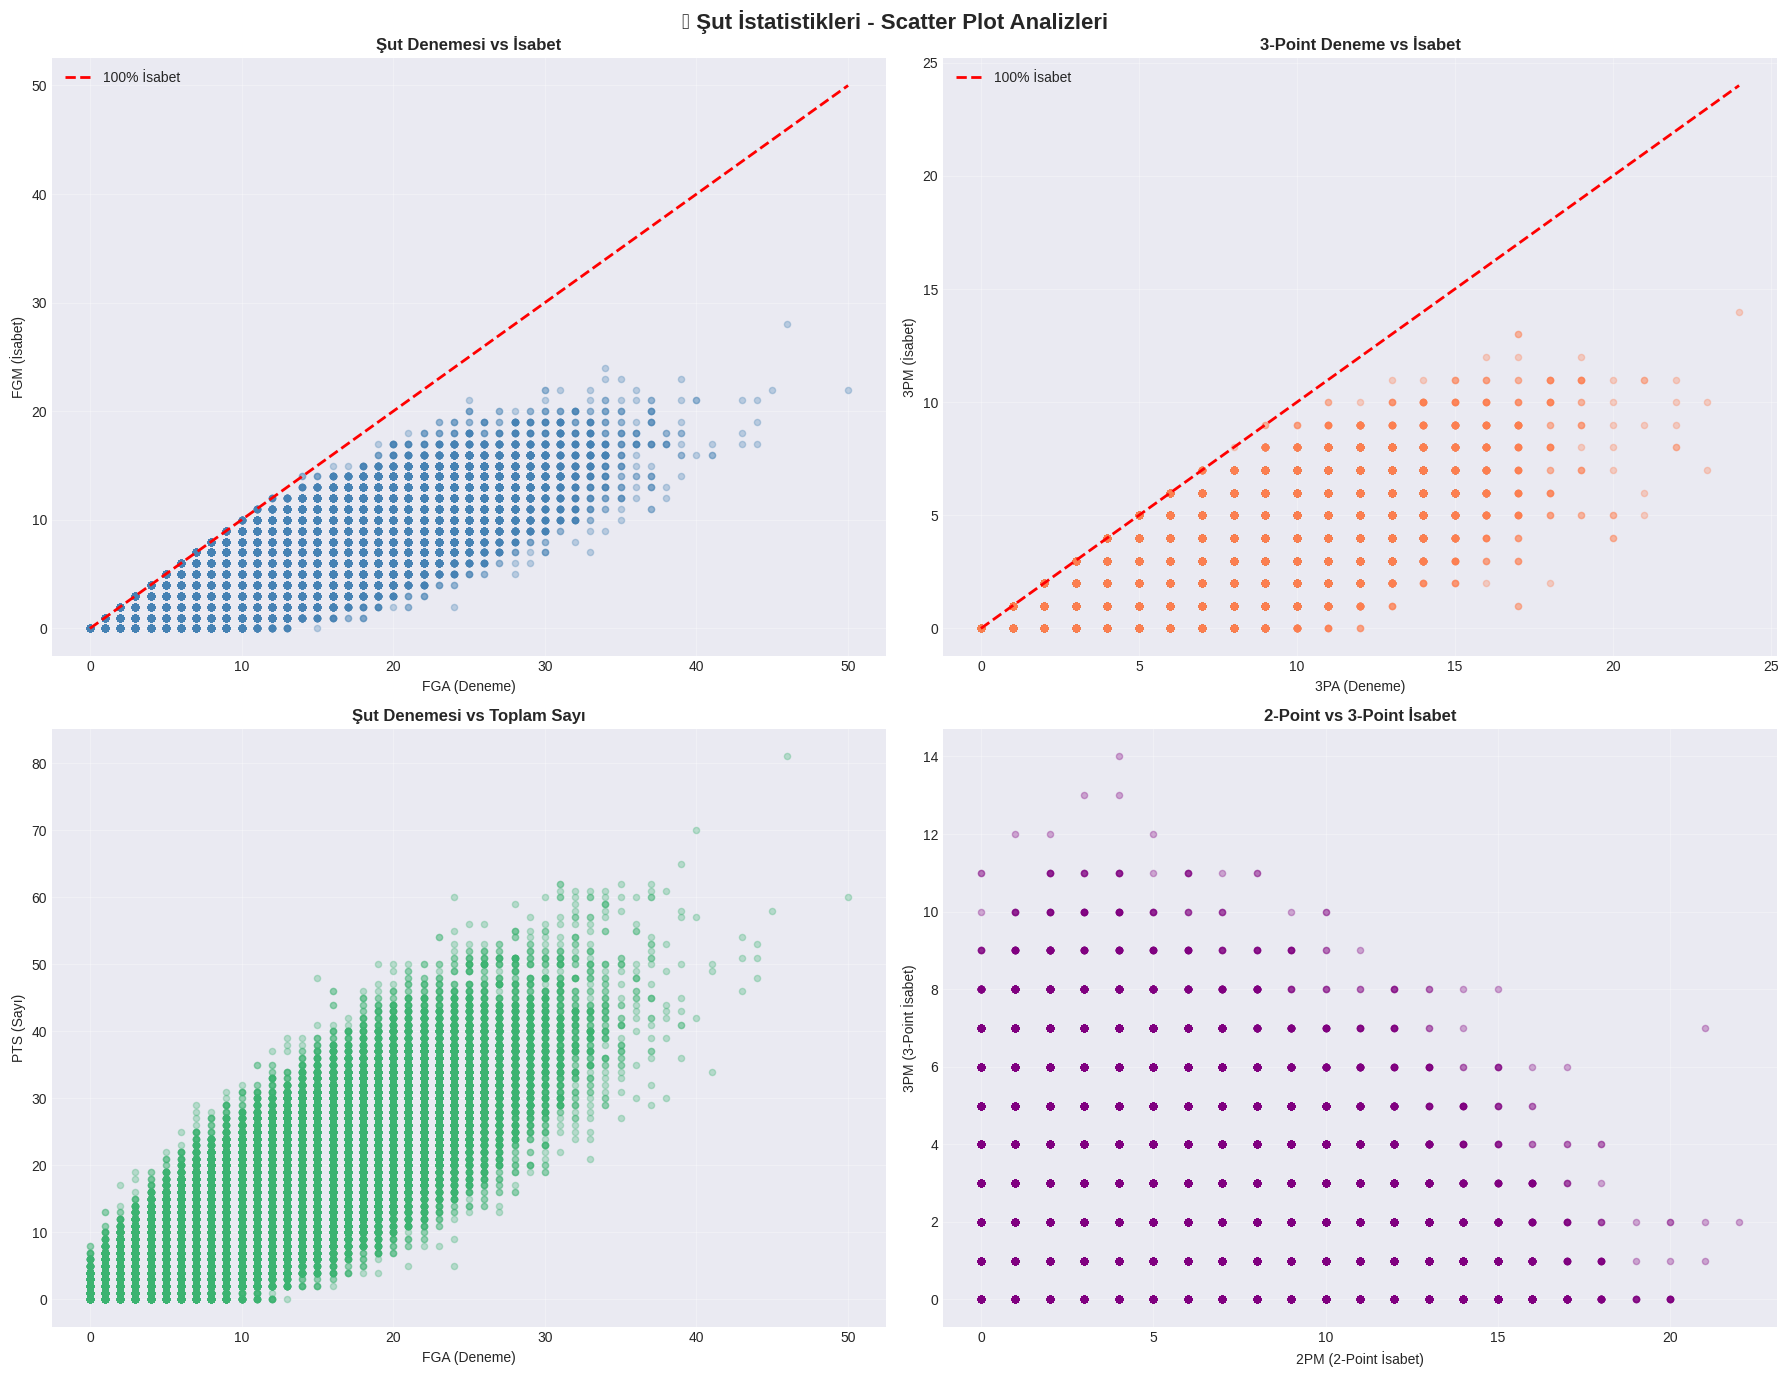

In [28]:
# Şut verileri scatter plot analizi
if 'FGM' in df.columns and 'FGA' in df.columns and 'FG3M' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('🎯 Şut İstatistikleri - Scatter Plot Analizleri',
                fontsize=16, fontweight='bold')

    # 1. FGM vs FGA
    axes[0, 0].scatter(df['FGA'], df['FGM'], alpha=0.3, s=20, color='steelblue')
    axes[0, 0].plot([0, df['FGA'].max()], [0, df['FGA'].max()], 'r--',
                   linewidth=2, label='100% İsabet')
    axes[0, 0].set_title('Şut Denemesi vs İsabet', fontweight='bold')
    axes[0, 0].set_xlabel('FGA (Deneme)')
    axes[0, 0].set_ylabel('FGM (İsabet)')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. 3PM vs 3PA
    if 'FG3A' in df.columns:
        axes[0, 1].scatter(df['FG3A'], df['FG3M'], alpha=0.3, s=20, color='coral')
        axes[0, 1].plot([0, df['FG3A'].max()], [0, df['FG3A'].max()], 'r--',
                       linewidth=2, label='100% İsabet')
        axes[0, 1].set_title('3-Point Deneme vs İsabet', fontweight='bold')
        axes[0, 1].set_xlabel('3PA (Deneme)')
        axes[0, 1].set_ylabel('3PM (İsabet)')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)

    # 3. PTS vs FGA (Şut verimliliği)
    if 'PTS' in df.columns:
        axes[1, 0].scatter(df['FGA'], df['PTS'], alpha=0.3, s=20, color='mediumseagreen')
        axes[1, 0].set_title('Şut Denemesi vs Toplam Sayı', fontweight='bold')
        axes[1, 0].set_xlabel('FGA (Deneme)')
        axes[1, 0].set_ylabel('PTS (Sayı)')
        axes[1, 0].grid(alpha=0.3)

    # 4. 2P vs 3P oranı
    if 'FG3M' in df.columns and 'FGM' in df.columns:
        df['FG2M'] = df['FGM'] - df['FG3M']
        axes[1, 1].scatter(df['FG2M'], df['FG3M'], alpha=0.3, s=20, color='purple')
        axes[1, 1].set_title('2-Point vs 3-Point İsabet', fontweight='bold')
        axes[1, 1].set_xlabel('2PM (2-Point İsabet)')
        axes[1, 1].set_ylabel('3PM (3-Point İsabet)')
        axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## ⏱️ Dakika Bazlı Performans Analizi

In [29]:
# Dakika bilgisini analiz et
if 'MIN' in df.columns:
    # String ise float'a çevir
    if df['MIN'].dtype == 'object':
        df['MIN_numeric'] = pd.to_numeric(df['MIN'].str.replace(':', '.'), errors='coerce')
    else:
        df['MIN_numeric'] = df['MIN']

    min_data = df['MIN_numeric'].dropna()

    print("="*70)
    print("⏱️ DAKİKA ANALİZİ")
    print("="*70)
    print(f"\nOrtalama Oyun Süresi: {min_data.mean():.2f} dakika")
    print(f"Medyan: {min_data.median():.2f} dakika")
    print(f"Std Sapma: {min_data.std():.2f}")
    print(f"Min: {min_data.min():.2f} dakika")
    print(f"Max: {min_data.max():.2f} dakika")
    print(f"Q1: {min_data.quantile(0.25):.2f} dakika")
    print(f"Q3: {min_data.quantile(0.75):.2f} dakika")

    # Kategorilere ayır
    df['MIN_category'] = pd.cut(df['MIN_numeric'],
                                bins=[0, 10, 20, 30, 40, 100],
                                labels=['0-10 dk', '10-20 dk', '20-30 dk', '30-40 dk', '40+ dk'])

    print("\n📊 Dakika Kategorileri:")
    min_cat_counts = df['MIN_category'].value_counts().sort_index()
    for cat, count in min_cat_counts.items():
        pct = (count / len(df)) * 100
        print(f"  {cat}: {count:,} ({pct:.2f}%)")

⏱️ DAKİKA ANALİZİ

Ortalama Oyun Süresi: 22.72 dakika
Medyan: 23.21 dakika
Std Sapma: 11.23
Min: -9.00 dakika
Max: 96.00 dakika
Q1: 14.37 dakika
Q3: 31.48 dakika

📊 Dakika Kategorileri:
  0-10 dk: 87,263 (13.05%)
  10-20 dk: 135,544 (20.27%)
  20-30 dk: 167,886 (25.11%)
  30-40 dk: 138,089 (20.65%)
  40+ dk: 29,480 (4.41%)


In [30]:
# Per-minute istatistikleri hesapla
if 'MIN_numeric' in df.columns and 'PTS' in df.columns:
    # Sıfır değil minimum 1 dakika oynamış oyuncular
    df_played = df[df['MIN_numeric'] > 1].copy()

    # Per-minute metrikleri
    df_played['PTS_per_min'] = df_played['PTS'] / df_played['MIN_numeric']

    if 'REB' in df.columns:
        df_played['REB_per_min'] = df_played['REB'] / df_played['MIN_numeric']
    if 'AST' in df.columns:
        df_played['AST_per_min'] = df_played['AST'] / df_played['MIN_numeric']
    if 'STL' in df.columns:
        df_played['STL_per_min'] = df_played['STL'] / df_played['MIN_numeric']
    if 'BLK' in df.columns:
        df_played['BLK_per_min'] = df_played['BLK'] / df_played['MIN_numeric']

    print("\n" + "="*70)
    print("📊 PER-MINUTE İSTATİSTİKLER")
    print("="*70)

    per_min_cols = [col for col in df_played.columns if '_per_min' in col]
    for col in per_min_cols:
        print(f"\n{col}:")
        print(f"  Ortalama: {df_played[col].mean():.3f}")
        print(f"  Medyan: {df_played[col].median():.3f}")
        print(f"  Max: {df_played[col].max():.3f}")


📊 PER-MINUTE İSTATİSTİKLER

PTS_per_min:
  Ortalama: 0.395
  Medyan: 0.375
  Max: 7.000

REB_per_min:
  Ortalama: 0.181
  Medyan: 0.155
  Max: 4.500

AST_per_min:
  Ortalama: 0.086
  Medyan: 0.063
  Max: 2.500

STL_per_min:
  Ortalama: 0.031
  Medyan: 0.000
  Max: 1.869

BLK_per_min:
  Ortalama: 0.021
  Medyan: 0.000
  Max: 1.987


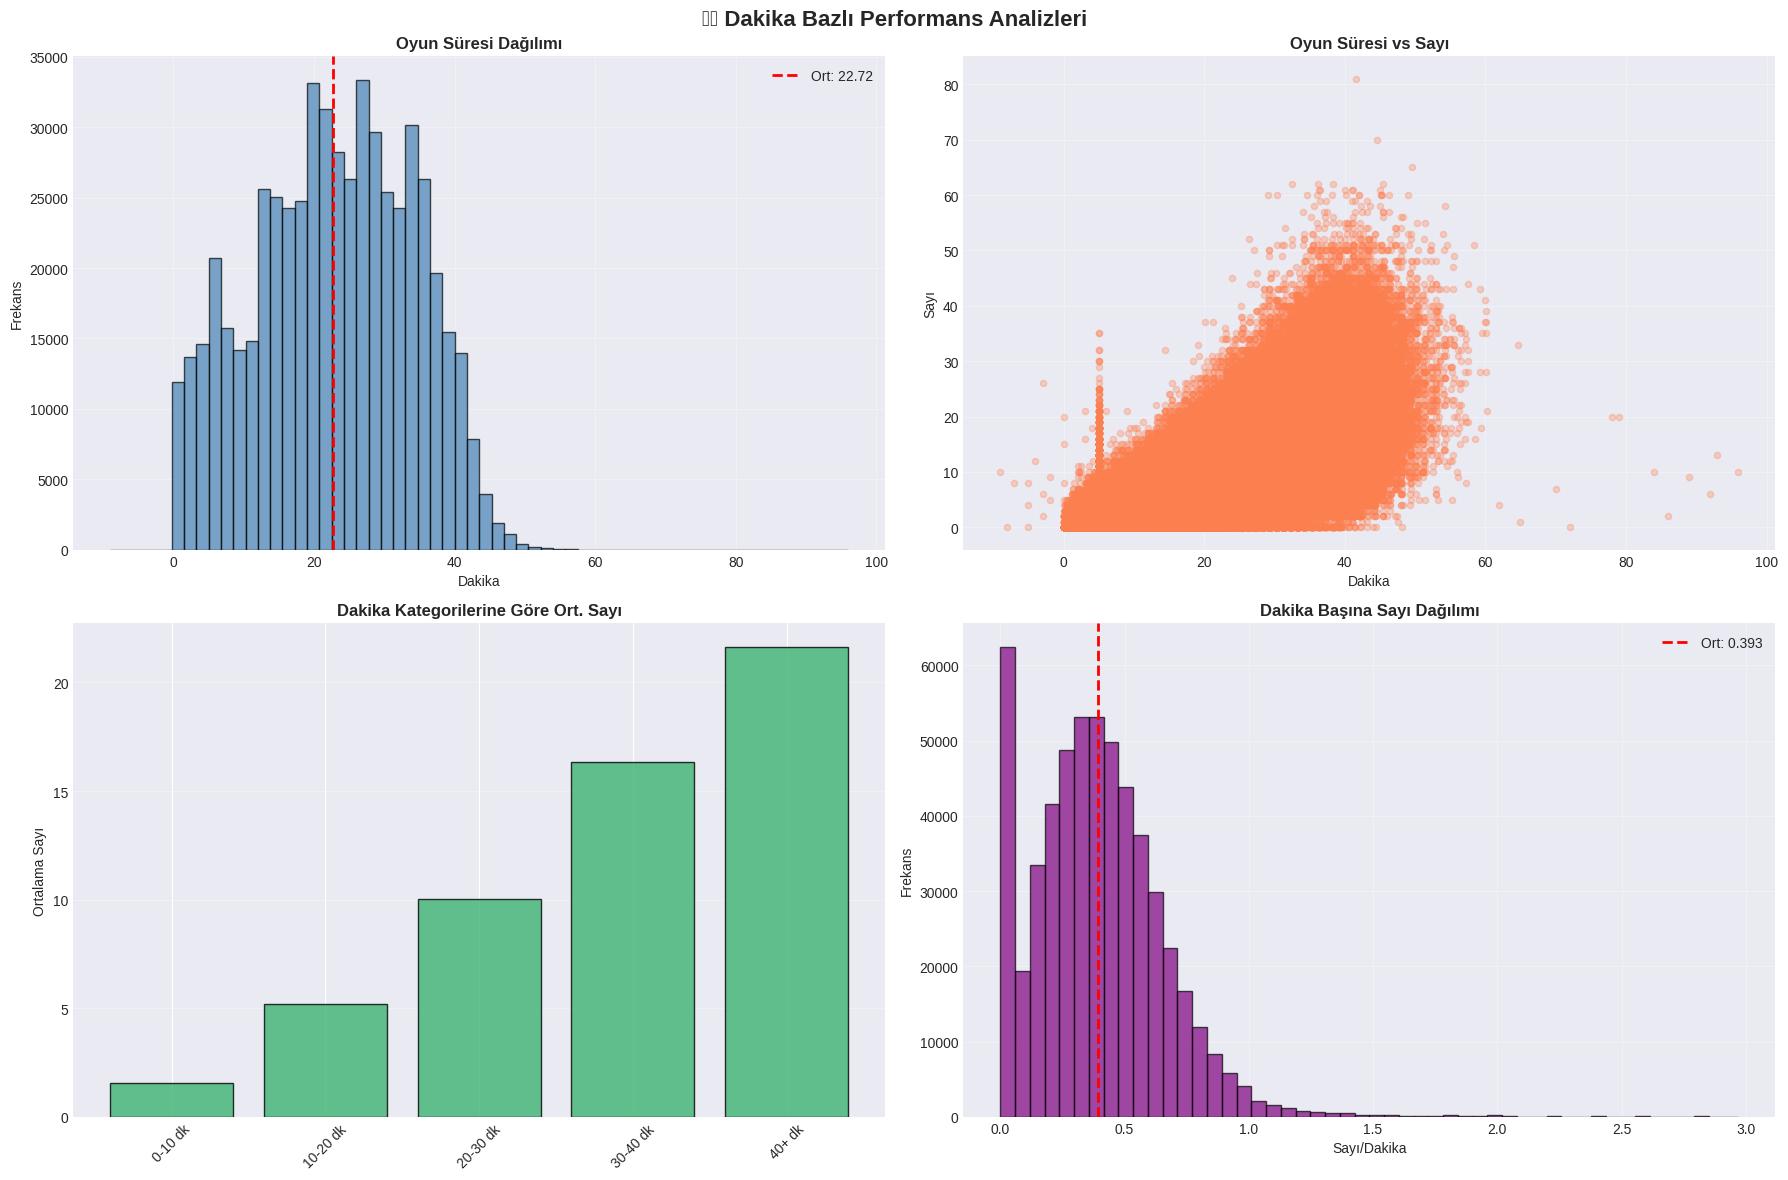

In [31]:
# Dakika bazlı görselleştirmeler
if 'MIN_numeric' in df.columns and 'PTS' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('⏱️ Dakika Bazlı Performans Analizleri',
                fontsize=16, fontweight='bold')

    # 1. Dakika dağılımı
    axes[0, 0].hist(min_data, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(min_data.mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {min_data.mean():.2f}")
    axes[0, 0].set_title('Oyun Süresi Dağılımı', fontweight='bold')
    axes[0, 0].set_xlabel('Dakika')
    axes[0, 0].set_ylabel('Frekans')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Dakika vs Sayı
    axes[0, 1].scatter(df['MIN_numeric'], df['PTS'], alpha=0.3, s=20, color='coral')
    axes[0, 1].set_title('Oyun Süresi vs Sayı', fontweight='bold')
    axes[0, 1].set_xlabel('Dakika')
    axes[0, 1].set_ylabel('Sayı')
    axes[0, 1].grid(alpha=0.3)

    # 3. Dakika kategorilerine göre ortalama sayı
    if 'MIN_category' in df.columns:
        cat_pts = df.groupby('MIN_category')['PTS'].mean()
        axes[1, 0].bar(range(len(cat_pts)), cat_pts.values,
                      color='mediumseagreen', edgecolor='black', alpha=0.8)
        axes[1, 0].set_xticks(range(len(cat_pts)))
        axes[1, 0].set_xticklabels(cat_pts.index, rotation=45)
        axes[1, 0].set_title('Dakika Kategorilerine Göre Ort. Sayı', fontweight='bold')
        axes[1, 0].set_ylabel('Ortalama Sayı')
        axes[1, 0].grid(axis='y', alpha=0.3)

    # 4. Per-minute sayı dağılımı
    if 'PTS_per_min' in df_played.columns:
        ppm_data = df_played['PTS_per_min'][df_played['PTS_per_min'] < 3]  # Outlier filtrele
        axes[1, 1].hist(ppm_data, bins=50, color='purple', edgecolor='black', alpha=0.7)
        axes[1, 1].axvline(ppm_data.mean(), color='red', linestyle='--',
                          linewidth=2, label=f"Ort: {ppm_data.mean():.3f}")
        axes[1, 1].set_title('Dakika Başına Sayı Dağılımı', fontweight='bold')
        axes[1, 1].set_xlabel('Sayı/Dakika')
        axes[1, 1].set_ylabel('Frekans')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 🔥 Triple-Double ve Double-Double Analizi

In [32]:
# Triple-Double ve Double-Double tespit et
if all(col in df.columns for col in ['PTS', 'REB', 'AST']):
    # Double-double kategorileri
    df['PTS_DD'] = df['PTS'] >= 10
    df['REB_DD'] = df['REB'] >= 10
    df['AST_DD'] = df['AST'] >= 10

    if 'STL' in df.columns:
        df['STL_DD'] = df['STL'] >= 10
    if 'BLK' in df.columns:
        df['BLK_DD'] = df['BLK'] >= 10

    # Double-double sayısı (en az 2 kategori)
    dd_cols = [col for col in df.columns if col.endswith('_DD')]
    df['DD_count'] = df[dd_cols].sum(axis=1)

    df['is_double_double'] = df['DD_count'] >= 2
    df['is_triple_double'] = df['DD_count'] >= 3
    df['is_quadruple_double'] = df['DD_count'] >= 4

    print("="*70)
    print("🔥 DOUBLE-DOUBLE / TRIPLE-DOUBLE ANALİZİ")
    print("="*70)

    dd_count = df['is_double_double'].sum()
    td_count = df['is_triple_double'].sum()
    qd_count = df['is_quadruple_double'].sum()

    print(f"\n📊 Double-Double: {dd_count:,} ({dd_count/len(df)*100:.2f}%)")
    print(f"📊 Triple-Double: {td_count:,} ({td_count/len(df)*100:.2f}%)")
    print(f"📊 Quadruple-Double: {qd_count:,} ({qd_count/len(df)*100:.2f}%)")

    if 'PLAYER_NAME' in df.columns and td_count > 0:
        print("\n" + "="*70)
        print("🏆 TÜM TRIPLE-DOUBLE PERFORMANSLARI")
        print("="*70)

        td_games = df[df['is_triple_double']].copy()
        cols_td = ['PLAYER_NAME', 'PTS', 'REB', 'AST']
        if 'STL' in df.columns:
            cols_td.append('STL')
        if 'BLK' in df.columns:
            cols_td.append('BLK')
        if 'TEAM_ABBREVIATION' in df.columns:
            cols_td.insert(1, 'TEAM_ABBREVIATION')

        print(td_games[cols_td].sort_values('PTS', ascending=False).to_string(index=False))

        # En çok triple-double yapan oyuncular
        td_by_player = td_games['PLAYER_NAME'].value_counts()
        print("\n" + "="*70)
        print("👑 EN ÇOK TRIPLE-DOUBLE YAPAN OYUNCULAR")
        print("="*70)
        for player, count in td_by_player.head(20).items():
            print(f"  {player}: {count} triple-double")

🔥 DOUBLE-DOUBLE / TRIPLE-DOUBLE ANALİZİ

📊 Double-Double: 43,975 (6.58%)
📊 Triple-Double: 1,367 (0.20%)
📊 Quadruple-Double: 0 (0.00%)

🏆 TÜM TRIPLE-DOUBLE PERFORMANSLARI
            PLAYER_NAME TEAM_ABBREVIATION    PTS    REB    AST    STL    BLK
           James Harden               HOU 60.000 10.000 11.000  4.000  1.000
      Russell Westbrook               OKC 57.000 13.000 11.000  3.000  0.000
           James Harden               HOU 53.000 16.000 17.000  0.000  0.000
      Russell Westbrook               OKC 51.000 10.000 13.000  4.000  1.000
           James Harden               HOU 51.000 13.000 13.000  2.000  1.000
      Russell Westbrook               OKC 51.000 13.000 10.000  2.000  0.000
           James Harden               HOU 50.000 11.000 10.000  0.000  0.000
      Russell Westbrook               OKC 50.000 16.000 10.000  1.000  0.000
           James Harden               HOU 50.000 10.000 11.000  2.000  0.000
           Nikola Jokic               DEN 49.000 14.000 10.0

## 📊 Korelasyon Analizi - Detaylı

In [33]:
# Sayısal sütunları seç (ID'ler hariç)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if not col.endswith('_ID')]

print("="*70)
print("📊 KORELASYON ANALİZİ")
print("="*70)
print(f"\nAnaliz edilen sütun sayısı: {len(numeric_cols)}")

# Korelasyon matrisi
corr_matrix = df[numeric_cols].corr()

# En yüksek korelasyonları bul
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((
            corr_matrix.columns[i],
            corr_matrix.columns[j],
            corr_matrix.iloc[i, j]
        ))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

print("\n🔝 EN YÜKSEK POZİTİF KORELASYONLAR (Top 30):")
print("="*70)
for idx, (col1, col2, corr) in enumerate(corr_pairs_sorted[:30], 1):
    print(f"{idx:2d}. {col1:20} <-> {col2:20} : {corr:7.4f}")

print("\n🔻 EN YÜKSEK NEGATİF KORELASYONLAR (Top 20):")
print("="*70)
neg_corr = sorted(corr_pairs, key=lambda x: x[2])[:20]
for idx, (col1, col2, corr) in enumerate(neg_corr, 1):
    print(f"{idx:2d}. {col1:20} <-> {col2:20} : {corr:7.4f}")

📊 KORELASYON ANALİZİ

Analiz edilen sütun sayısı: 26

🔝 EN YÜKSEK POZİTİF KORELASYONLAR (Top 30):
 1. MIN_numeric_converted <-> MIN_numeric          :  1.0000
 2. FT_PCT               <-> FT_PCT_calc          :  1.0000
 3. FG3_PCT              <-> FG3_PCT_calc         :  1.0000
 4. FG_PCT               <-> FG_PCT_calc          :  1.0000
 5. FGM                  <-> PTS                  :  0.9606
 6. FTM                  <-> FTA                  :  0.9507
 7. DREB                 <-> REB                  :  0.9294
 8. FGM                  <-> FG2M                 :  0.9150
 9. FGM                  <-> FGA                  :  0.8848
10. FGA                  <-> PTS                  :  0.8820
11. PTS                  <-> FG2M                 :  0.8350
12. FG3M                 <-> FG3A                 :  0.8219
13. FGA                  <-> FG2M                 :  0.7937
14. FGA                  <-> MIN_numeric_converted :  0.7906
15. FGA                  <-> MIN_numeric          :  0.7906


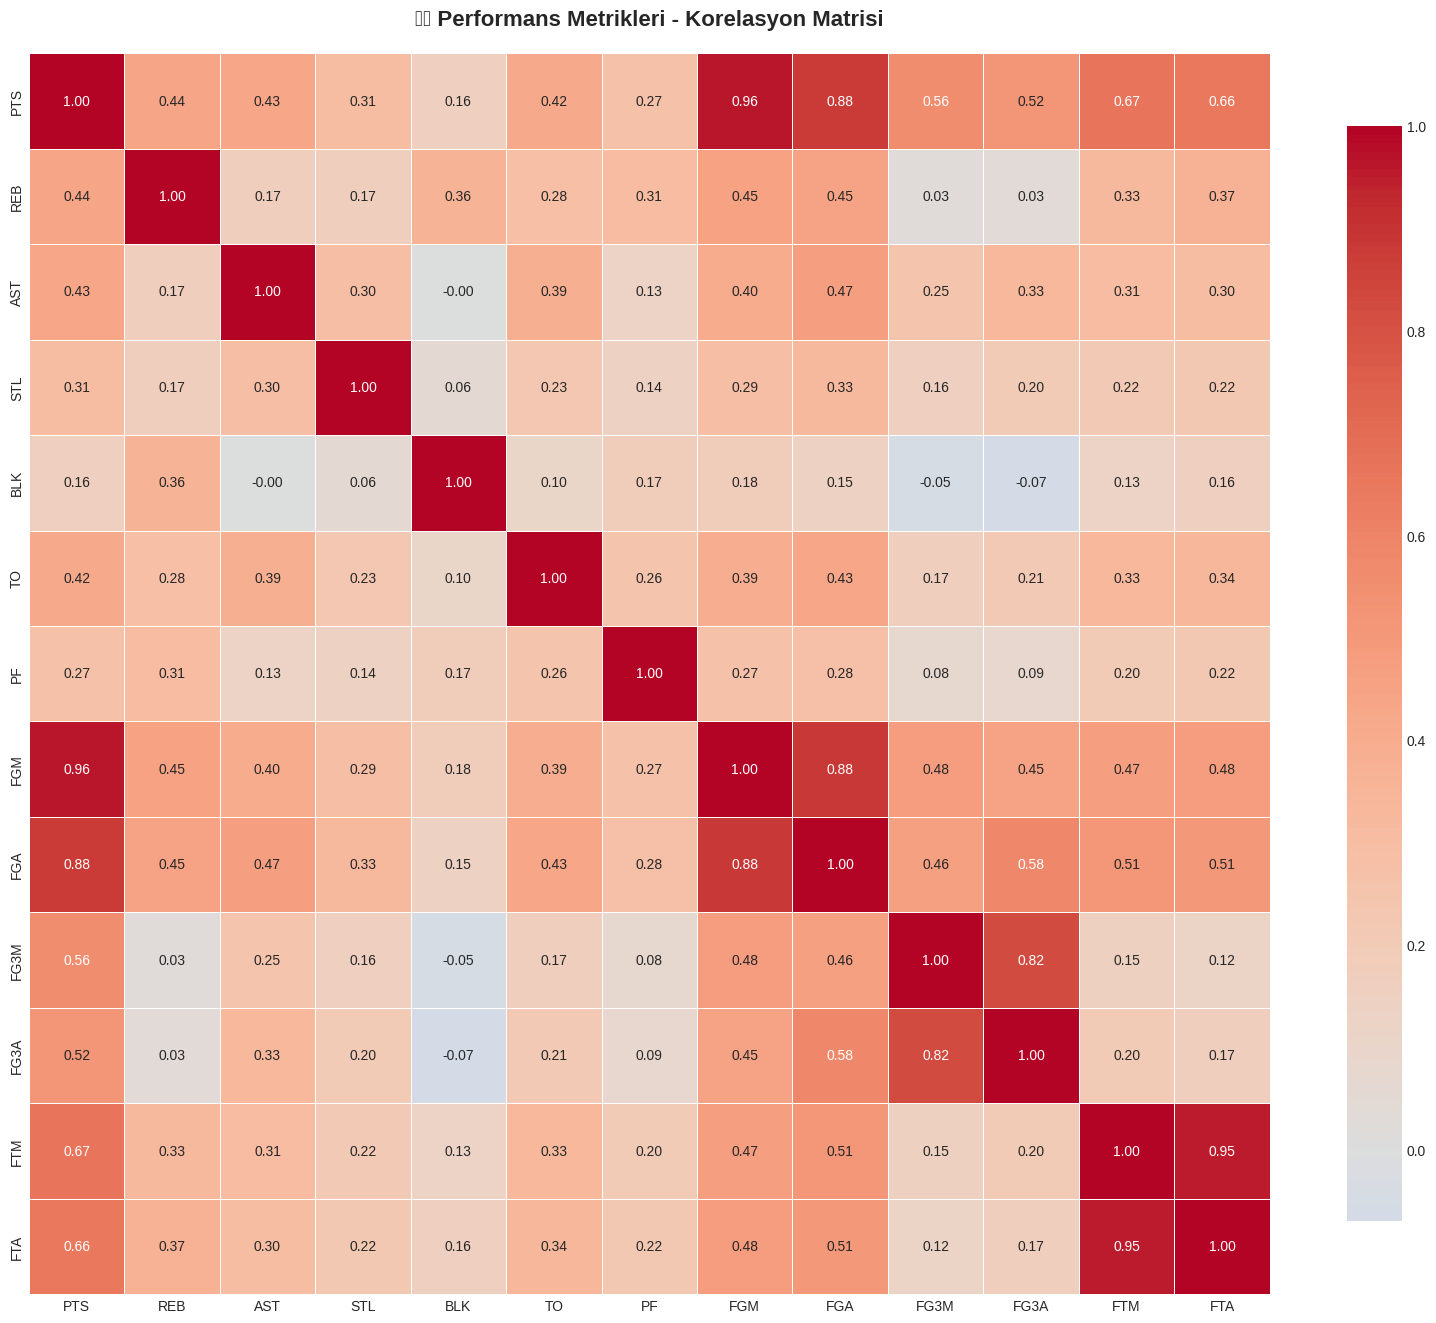

In [34]:
# Korelasyon heatmap - Performans metrikleri
perf_metrics = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TO', 'PF',
               'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA']
perf_metrics = [col for col in perf_metrics if col in df.columns]

if len(perf_metrics) > 2:
    corr_perf = df[perf_metrics].corr()

    plt.figure(figsize=(16, 14))
    sns.heatmap(corr_perf, annot=True, fmt=".2f", cmap='coolwarm',
               center=0, linewidths=0.5, cbar_kws={"shrink": 0.8},
               square=True)
    plt.title('⛹️ Performans Metrikleri - Korelasyon Matrisi',
             fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

## 👥 Oyuncu Bazlı Toplam İstatistikler

In [35]:
# Her oyuncu için toplam istatistikler
if 'PLAYER_NAME' in df.columns:
    agg_dict = {'GAME_ID': 'count'}

    if 'PTS' in df.columns:
        agg_dict['PTS'] = ['sum', 'mean', 'max', 'std']
    if 'REB' in df.columns:
        agg_dict['REB'] = ['sum', 'mean', 'max']
    if 'AST' in df.columns:
        agg_dict['AST'] = ['sum', 'mean', 'max']
    if 'STL' in df.columns:
        agg_dict['STL'] = ['sum', 'mean']
    if 'BLK' in df.columns:
        agg_dict['BLK'] = ['sum', 'mean']
    if 'TO' in df.columns:
        agg_dict['TO'] = ['sum', 'mean']

    player_stats = df.groupby('PLAYER_NAME').agg(agg_dict).round(2)

    player_stats.columns = ['_'.join(col) if col[1] else col[0]
                            for col in player_stats.columns]
    player_stats = player_stats.rename(columns={'GAME_ID_count': 'Games_Played'})

    # En çok maç oynayan oyuncular
    print("="*70)
    print("🏀 EN ÇOK MAÇ OYNAYAN OYUNCULAR (Top 30)")
    print("="*70)
    top_players_games = player_stats.nlargest(30, 'Games_Played')
    print(top_players_games)

    if 'PTS_sum' in player_stats.columns:
        # En çok sayı atan oyuncular (toplam)
        print("\n" + "="*70)
        print("🏆 EN ÇOK TOPLAM SAYI ATAN OYUNCULAR (Top 30)")
        print("="*70)
        cols_to_show = ['PTS_sum', 'PTS_mean', 'PTS_max', 'Games_Played']
        top_scorers_total = player_stats.nlargest(30, 'PTS_sum')[cols_to_show]
        print(top_scorers_total)

        # En yüksek ortalama (minimum 50 maç)
        qualified = player_stats[player_stats['Games_Played'] >= 50]
        print("\n" + "="*70)
        print("⭐ EN YÜKSEK ORTALAMA SAYI (Min 50 Maç) - Top 30")
        print("="*70)
        top_avg_scorers = qualified.nlargest(30, 'PTS_mean')[cols_to_show]
        print(top_avg_scorers)

🏀 EN ÇOK MAÇ OYNAYAN OYUNCULAR (Top 30)
                   Games_Played   PTS_sum  PTS_mean  PTS_max  PTS_std  \
PLAYER_NAME                                                             
LeBron James               1795 46638.000    26.830   61.000    8.200   
Udonis Haslem              1720  7828.000     7.230   28.000    5.420   
Andre Iguodala             1560 16422.000    11.010   34.000    7.150   
Dwight Howard              1541 22494.000    15.550   46.000    8.100   
Kyle Korver                1534 13925.000     9.550   31.000    5.970   
Chris Paul                 1520 25086.000    17.880   43.000    7.550   
Carmelo Anthony            1518 31658.000    22.170   62.000    9.000   
Vince Carter               1470 20404.000    14.760   51.000    9.840   
Trevor Ariza               1451 13438.000    10.310   40.000    6.300   
Tony Parker                1420 21612.000    16.070   55.000    8.010   
Lou Williams               1407 17604.000    13.600   50.000    7.950   
Jamal Crawf

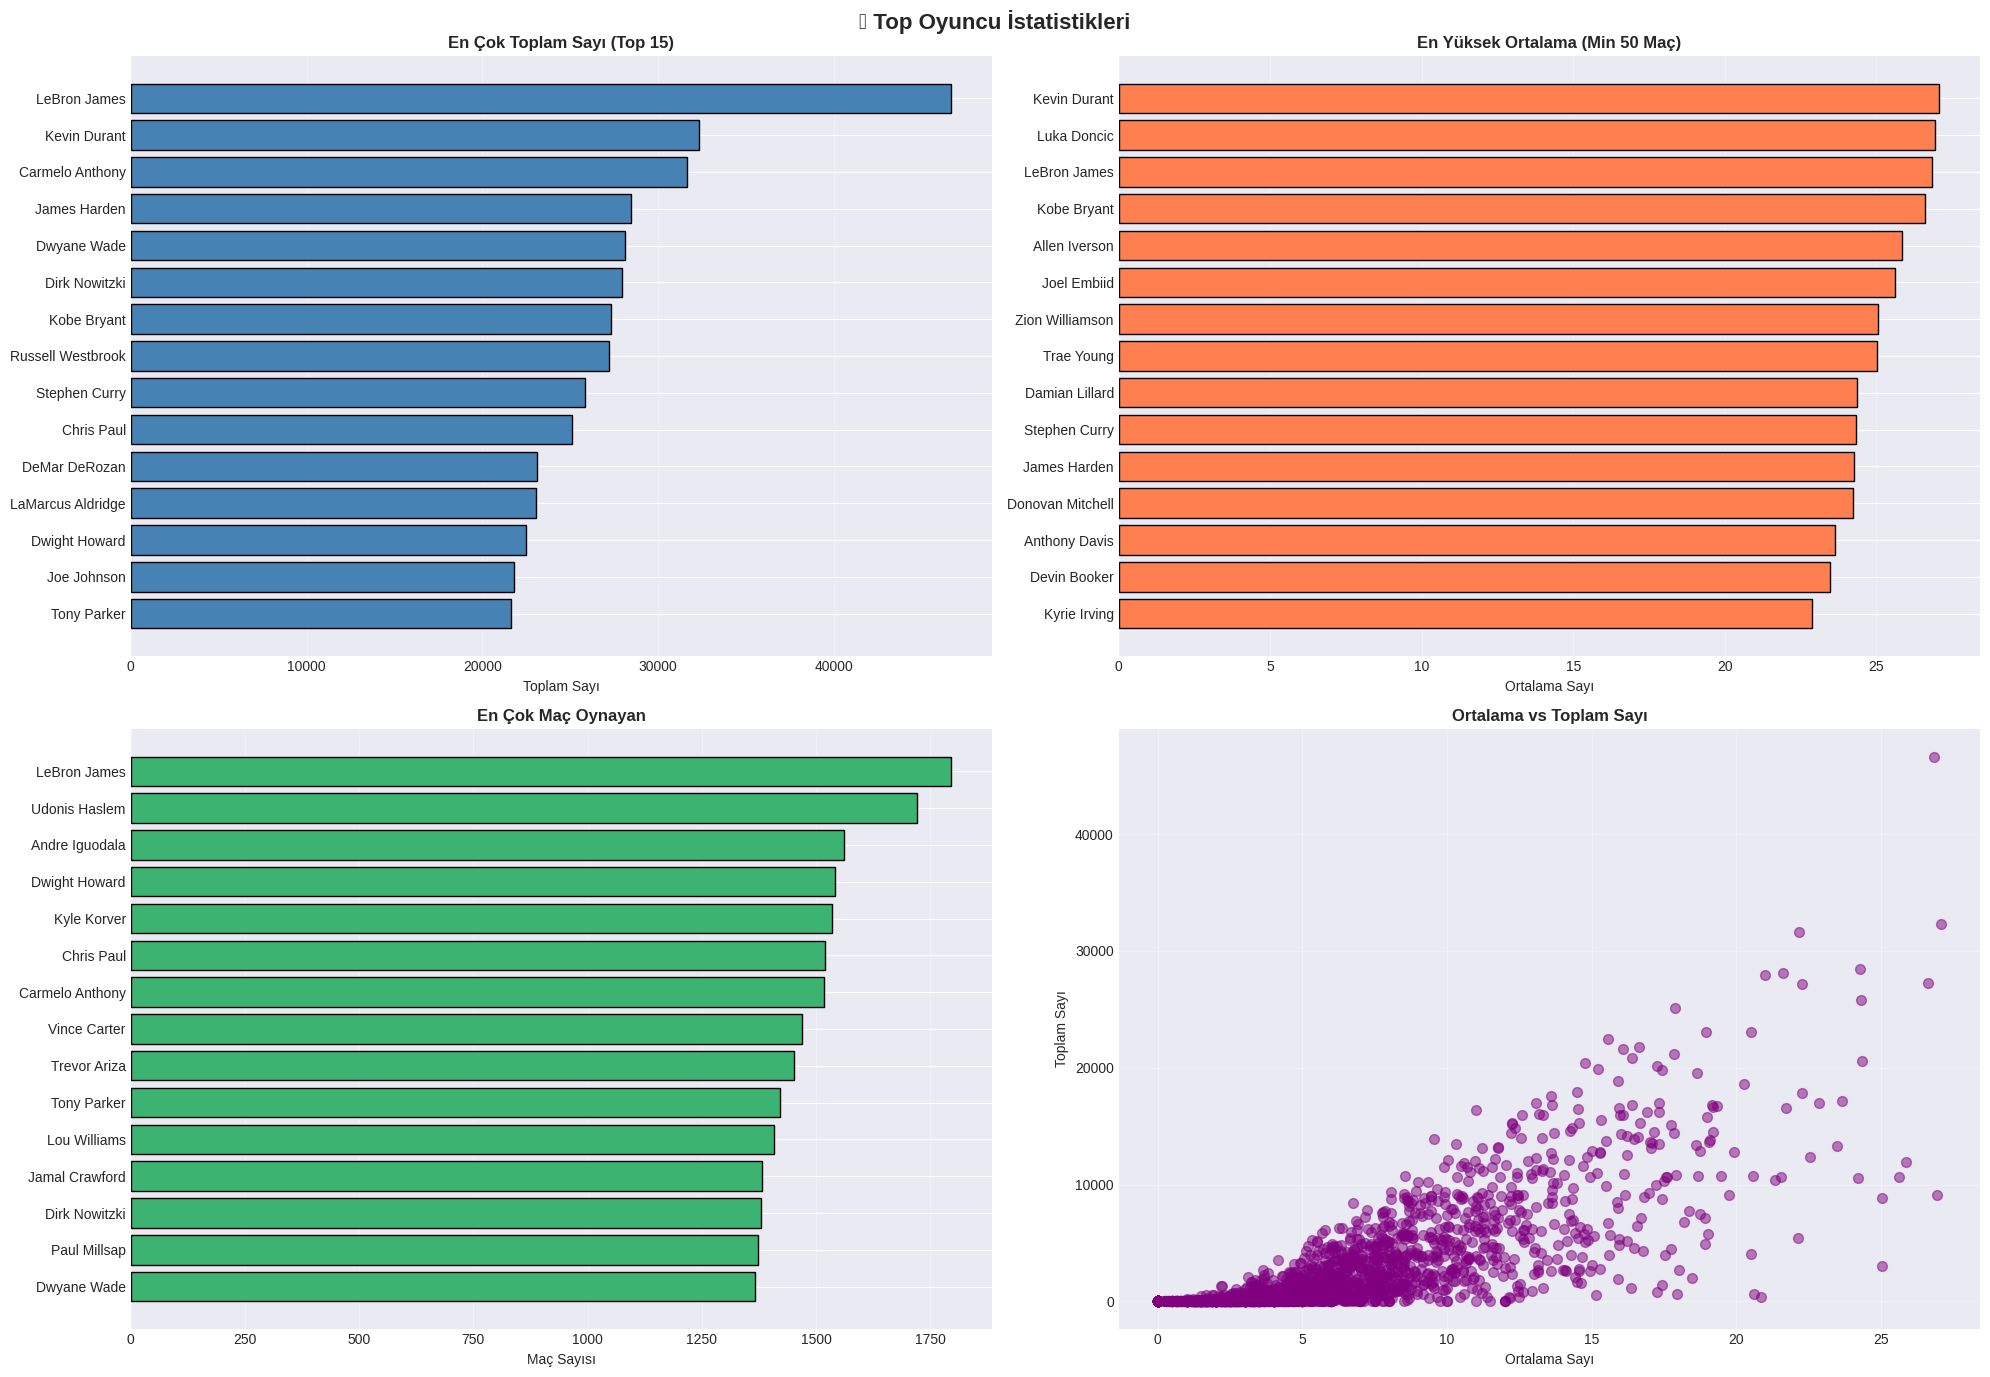

In [36]:
# Görselleştirme: Top oyuncular
if 'PTS_sum' in player_stats.columns:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('👑 Top Oyuncu İstatistikleri',
                fontsize=16, fontweight='bold')

    # 1. En çok sayı (toplam)
    top_15_total = player_stats.nlargest(15, 'PTS_sum')
    axes[0, 0].barh(range(15), top_15_total['PTS_sum'],
                   color='steelblue', edgecolor='black')
    axes[0, 0].set_yticks(range(15))
    axes[0, 0].set_yticklabels(top_15_total.index)
    axes[0, 0].set_xlabel('Toplam Sayı')
    axes[0, 0].set_title('En Çok Toplam Sayı (Top 15)', fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
    axes[0, 0].invert_yaxis()

    # 2. En yüksek ortalama
    qualified = player_stats[player_stats['Games_Played'] >= 50]
    top_15_avg = qualified.nlargest(15, 'PTS_mean')
    axes[0, 1].barh(range(15), top_15_avg['PTS_mean'],
                   color='coral', edgecolor='black')
    axes[0, 1].set_yticks(range(15))
    axes[0, 1].set_yticklabels(top_15_avg.index)
    axes[0, 1].set_xlabel('Ortalama Sayı')
    axes[0, 1].set_title('En Yüksek Ortalama (Min 50 Maç)', fontweight='bold')
    axes[0, 1].grid(axis='x', alpha=0.3)
    axes[0, 1].invert_yaxis()

    # 3. En çok maç
    top_15_games = player_stats.nlargest(15, 'Games_Played')
    axes[1, 0].barh(range(15), top_15_games['Games_Played'],
                   color='mediumseagreen', edgecolor='black')
    axes[1, 0].set_yticks(range(15))
    axes[1, 0].set_yticklabels(top_15_games.index)
    axes[1, 0].set_xlabel('Maç Sayısı')
    axes[1, 0].set_title('En Çok Maç Oynayan', fontweight='bold')
    axes[1, 0].grid(axis='x', alpha=0.3)
    axes[1, 0].invert_yaxis()

    # 4. Scatter: Toplam vs Ortalama
    axes[1, 1].scatter(player_stats['PTS_mean'], player_stats['PTS_sum'],
                      alpha=0.5, s=50, color='purple')
    axes[1, 1].set_xlabel('Ortalama Sayı')
    axes[1, 1].set_ylabel('Toplam Sayı')
    axes[1, 1].set_title('Ortalama vs Toplam Sayı', fontweight='bold')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 📝 GAMES_DETAILS.CSV - Kapsamlı Özet Raporu

In [ ]:
# Final kapsamlı özet
print("\n" + "="*80)
print("📝 GAMES_DETAILS.CSV - KAPSAMLI ÖZET RAPOR")
print("="*80)

print(f"\n🎯 VERİ SETİ:")
print(f"  • Toplam Kayıt: {len(df):,}")
print(f"  • Sütun Sayısı: {len(df.columns)}")
print(f"  • Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if 'PLAYER_ID' in df.columns:
    print(f"\n👥 OYUNCU BİLGİLERİ:")
    print(f"  • Benzersiz Oyuncu: {df['PLAYER_ID'].nunique():,}")

if 'GAME_ID' in df.columns:
    print(f"  • Benzersiz Maç: {df['GAME_ID'].nunique():,}")
    print(f"  • Ort. Oyuncu/Maç: {len(df) / df['GAME_ID'].nunique():.1f}")

if 'PTS' in df.columns:
    print(f"\n⛹️ PERFORMANS İSTATİSTİKLERİ:")
    print(f"  • Ort. Sayı (Per Game): {df['PTS'].mean():.2f}")
    print(f"  • Max Tek Maç Sayı: {df['PTS'].max():.0f}")
    print(f"  • Toplam Atılan Sayı: {df['PTS'].sum():,.0f}")

if 'REB' in df.columns:
    print(f"  • Ort. Ribaund: {df['REB'].mean():.2f}")
    print(f"  • Max Tek Maç Ribaund: {df['REB'].max():.0f}")

if 'AST' in df.columns:
    print(f"  • Ort. Asist: {df['AST'].mean():.2f}")
    print(f"  • Max Tek Maç Asist: {df['AST'].max():.0f}")

if 'MIN_numeric' in df.columns:
    print(f"\n⏱️ OYUN SÜRESİ:")
    print(f"  • Ort. Dakika: {df['MIN_numeric'].mean():.2f}")
    print(f"  • Medyan Dakika: {df['MIN_numeric'].median():.2f}")

if 'FG_PCT_calc' in df.columns:
    print(f"\n🎯 ŞUT VERİMLİLİĞİ:")
    print(f"  • Ort. FG%: {df['FG_PCT_calc'].mean():.3f}")
    if 'FG3_PCT_calc' in df.columns:
        print(f"  • Ort. 3P%: {df['FG3_PCT_calc'].mean():.3f}")
    if 'FT_PCT_calc' in df.columns:
        print(f"  • Ort. FT%: {df['FT_PCT_calc'].mean():.3f}")

if 'is_triple_double' in df.columns:
    print(f"\n🔥 ÖZEL PERFORMANSLAR:")
    print(f"  • Triple-Double: {df['is_triple_double'].sum():,}")
    print(f"  • Double-Double: {df['is_double_double'].sum():,}")

print(f"\n📊 VERİ KALİTESİ:")
total_cells = len(df) * len(df.columns)
missing_cells = df.isnull().sum().sum()
print(f"  • Toplam Hücre: {total_cells:,}")
print(f"  • Eksik Hücre: {missing_cells:,}")
print(f"  • Eksiklik Oranı: {(missing_cells/total_cells*100):.2f}%")

print("\n" + "="*80)
print("✅ GAMES_DETAILS.CSV KAPSAMLI ANALİZİ TAMAMLANDI!")
print("="*80)
print("\n💡 Sonraki Adımlar:")
print("  • Oyuncu efficiency rating modelleri geliştirin")
print("  • Makine öğrenmesi ile performans tahmini yapın")
print("  • Oyuncu karşılaştırmaları yapın")
print("  • Advanced metrics hesaplayın (PER, TS%, etc.)")
print("\n" + "="*80)